In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ddf-pub")

In [2]:
BASE_PATH = Path("/eos/user/i/idioniso/sndMuTri/data")
MC_PATH = (
    BASE_PATH / "trimuon_boost100_looseCuts7/trimuon_boost100_looseCuts7.parquet"
)
DATA_PATH = BASE_PATH / "run_006640/run6640_looseCuts7_hough.parquet"
GALLERY_PATH = (
    BASE_PATH
    / "gallery_looseCuts7/mu3_search_hough_looseCuts7_combined.parquet"
)

In [3]:
LUMI_SUB_DATA = 0.040777061918046364
LUMI_FULL_6640 = 0.9915864253712848
LUMI_MC_DATASET = 0.0250

SCALE_TO_FULL = LUMI_FULL_6640 / LUMI_MC_DATASET
SCALE_TO_1FB = 1.00 / LUMI_MC_DATASET

## Data loading & MC Signal Setup

In [4]:
mc_df = pd.read_parquet(MC_PATH)
data = pd.read_parquet(DATA_PATH)
gallery = pd.read_parquet(GALLERY_PATH)
gallery_6640 = gallery[gallery["run_id"] == 6640]

In [5]:
sig_rock_mask = (mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)
sig_rock_idx = mc_df.index[sig_rock_mask]
w_rock_raw = mc_df.loc[sig_rock_idx, "mc_weight"].to_numpy()
tot_rock_1fb = w_rock_raw.sum() * SCALE_TO_1FB

In [6]:
dfs = {
    "mc_df": mc_df,
    "data": data,
    "gallery": gallery,
    "gallery_6640": gallery_6640,
}

# Individual breakdowns
for name, df in dfs.items():
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"{name:15}: {mem_mb:8.2f} MB")

# Combined total
total_bytes = sum(df.memory_usage(deep=True).sum() for df in dfs.values())
print("-" * 30)
print(f"Total RAM:       {total_bytes / (1024**2):8.2f} MB")
print(f"Total RAM:       {total_bytes / (1024**3):8.2f} GB")

mc_df          :  1534.52 MB
data           :  1634.71 MB
gallery        :     1.48 MB
gallery_6640   :     0.14 MB
------------------------------
Total RAM:        3170.86 MB
Total RAM:           3.10 GB


## Toplogical Criteria Evaluation

### Helper Functions

In [7]:
# ==============================================================================
# 2. HELPER FUNCTIONS
# ==============================================================================
def check_nc(
    df: pd.DataFrame,
    prefix: str,
    proj: str,
    z_min: float,
    z_max: float,
    strict: bool = True,
) -> np.ndarray:
    """Evaluates pairwise line non-crossing within detector Z-range [z_min, z_max].

    Parameters
    ----------
    strict : bool
        If True, requires >= 2 lines to evaluate non-crossing (returns False if <= 1 line).
        If False, evaluates 0 or 1 line as passing vacuously.
    """
    n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
    m1, c1 = (
        df[f"{proj}_{prefix}_m1"].to_numpy(),
        df[f"{proj}_{prefix}_c1"].to_numpy(),
    )
    m2, c2 = (
        df[f"{proj}_{prefix}_m2"].to_numpy(),
        df[f"{proj}_{prefix}_c2"].to_numpy(),
    )
    m3, c3 = (
        df[f"{proj}_{prefix}_m3"].to_numpy(),
        df[f"{proj}_{prefix}_c3"].to_numpy(),
    )

    x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
    x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
    x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3

    no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
    no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
    no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0

    pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
    pass_2 = (n == 2) & no_cross_12

    if strict:
        return pass_3 | pass_2
    return pass_3 | pass_2 | (n <= 1)


def get_system_components(df: pd.DataFrame):
    """Builds all 9 multiplicity patterns and 5 collinearity modes for SF and DS."""
    nx_sf, ny_sf = (
        df["n_lines_sf_xz"].to_numpy(),
        df["n_lines_sf_yz"].to_numpy(),
    )
    nx_ds, ny_ds = (
        df["n_lines_ds_xz"].to_numpy(),
        df["n_lines_ds_yz"].to_numpy(),
    )

    # 9 Canonical Multiplicity Patterns
    mult_sf = {
        "(3,3)": (nx_sf >= 3) & (ny_sf >= 3),
        "(3,2)": (
            ((nx_sf >= 3) & (ny_sf >= 2)) | ((ny_sf >= 3) & (nx_sf >= 2))
        ),
        "(3,1)": (
            ((nx_sf >= 3) & (ny_sf >= 1)) | ((ny_sf >= 3) & (nx_sf >= 1))
        ),
        "(3,0)": (nx_sf >= 3) | (ny_sf >= 3),
        "(2,2)": (nx_sf >= 2) & (ny_sf >= 2),
        "(2,1)": (
            ((nx_sf >= 2) & (ny_sf >= 1)) | ((ny_sf >= 2) & (nx_sf >= 1))
        ),
        "(2,0)": (nx_sf >= 2) | (ny_sf >= 2),
        "(1,1)": (nx_sf >= 1) & (ny_sf >= 1),
        "(1,0)": (nx_sf >= 1) | (ny_sf >= 1),
    }

    mult_ds = {
        "(3,3)": (nx_ds >= 3) & (ny_ds >= 3),
        "(3,2)": (
            ((nx_ds >= 3) & (ny_ds >= 2)) | ((ny_ds >= 3) & (nx_ds >= 2))
        ),
        "(3,1)": (
            ((nx_ds >= 3) & (ny_ds >= 1)) | ((ny_ds >= 3) & (nx_ds >= 1))
        ),
        "(3,0)": (nx_ds >= 3) | (ny_ds >= 3),
        "(2,2)": (nx_ds >= 2) & (ny_ds >= 2),
        "(2,1)": (
            ((nx_ds >= 2) & (ny_ds >= 1)) | ((ny_ds >= 2) & (nx_ds >= 1))
        ),
        "(2,0)": (nx_ds >= 2) | (ny_ds >= 2),
        "(1,1)": (nx_ds >= 1) & (ny_ds >= 1),
        "(1,0)": (nx_ds >= 1) | (ny_ds >= 1),
    }

    # Strict Non-Crossing
    nc_sf_xz_s = check_nc(df, "sf", "xz", 260.0, 355.0, strict=True)
    nc_sf_yz_s = check_nc(df, "sf", "yz", 260.0, 355.0, strict=True)
    nc_ds_xz_s = check_nc(df, "ds", "xz", 460.0, 590.0, strict=True)
    nc_ds_yz_s = check_nc(df, "ds", "yz", 460.0, 590.0, strict=True)

    # Physical Non-Crossing (<= 1 line passes vacuously)
    nc_sf_xz_p = check_nc(df, "sf", "xz", 260.0, 355.0, strict=False)
    nc_sf_yz_p = check_nc(df, "sf", "yz", 260.0, 355.0, strict=False)
    nc_ds_xz_p = check_nc(df, "ds", "xz", 460.0, 590.0, strict=False)
    nc_ds_yz_p = check_nc(df, "ds", "yz", 460.0, 590.0, strict=False)

    # 5 Collinearity Modes
    coll_sf = {
        "OFF": np.ones(len(df), dtype=bool),
        "OR": nc_sf_xz_s | nc_sf_yz_s,
        "AND": nc_sf_xz_s & nc_sf_yz_s,
        "OR_phys": nc_sf_xz_p | nc_sf_yz_p,
        "AND_phys": nc_sf_xz_p & nc_sf_yz_p,
    }
    coll_ds = {
        "OFF": np.ones(len(df), dtype=bool),
        "OR": nc_ds_xz_s | nc_ds_yz_s,
        "AND": nc_ds_xz_s & nc_ds_yz_s,
        "OR_phys": nc_ds_xz_p | nc_ds_yz_p,
        "AND_phys": nc_ds_xz_p & nc_ds_yz_p,
    }

    return mult_sf, mult_ds, coll_sf, coll_ds


def parse_k(k: str) -> list:
    """Parses composite key string format into [n1, n2, coll_setting]."""
    parts = k.split("_")
    p = parts[0]
    c = "_".join(parts[1:])
    n1, n2 = [int(x) for x in p.strip("()").split(",")]
    return [n1, n2, c]

### Topology Generation

In [8]:
m_sf_mc, m_ds_mc, c_sf_mc, c_ds_mc = get_system_components(mc_df)
m_sf_dt, m_ds_dt, c_sf_dt, c_ds_dt = get_system_components(data)
m_sf_gal, m_ds_gal, c_sf_gal, c_ds_gal = get_system_components(gallery_6640)

# Build 45 single-system criteria per detector (9 patterns x 5 collinearity modes)
crit_sf_mc = {
    f"{m}_{c}": m_sf_mc[m] & c_sf_mc[c] for m in m_sf_mc for c in c_sf_mc
}
crit_ds_mc = {
    f"{m}_{c}": m_ds_mc[m] & c_ds_mc[c] for m in m_ds_mc for c in c_ds_mc
}
crit_sf_dt = {
    f"{m}_{c}": m_sf_dt[m] & c_sf_dt[c] for m in m_sf_dt for c in c_sf_dt
}
crit_ds_dt = {
    f"{m}_{c}": m_ds_dt[m] & c_ds_dt[c] for m in m_ds_dt for c in c_ds_dt
}
crit_sf_gal = {
    f"{m}_{c}": m_sf_gal[m] & c_sf_gal[c] for m in m_sf_gal for c in c_sf_gal
}
crit_ds_gal = {
    f"{m}_{c}": m_ds_gal[m] & c_ds_gal[c] for m in m_ds_gal for c in c_ds_gal
}

keys_45 = list(crit_sf_mc.keys())
all_entries = []

# ==============================================================================
# 4. TOPOLOGY GENERATION (3,366 Total Configurations)
# ==============================================================================
# A. Modular Subspace (3,150 configurations)
for k in keys_45:
    all_entries.append(
        (
            "SF_ONLY",
            f"('SF_ONLY', {parse_k(k)}, None)",
            crit_sf_mc[k],
            crit_sf_dt[k],
            crit_sf_gal[k],
        )
    )

for k in keys_45:
    all_entries.append(
        (
            "DS_ONLY",
            f"('DS_ONLY', None, {parse_k(k)})",
            crit_ds_mc[k],
            crit_ds_dt[k],
            crit_ds_gal[k],
        )
    )

for k_sf in keys_45:
    for k_ds in keys_45:
        all_entries.append(
            (
                "MODULAR_AND",
                f"('AND', {parse_k(k_sf)}, {parse_k(k_ds)})",
                crit_sf_mc[k_sf] & crit_ds_mc[k_ds],
                crit_sf_dt[k_sf] & crit_ds_dt[k_ds],
                crit_sf_gal[k_sf] & crit_ds_gal[k_ds],
            )
        )

for i in range(len(keys_45)):
    for j in range(i, len(keys_45)):
        k_sf, k_ds = keys_45[i], keys_45[j]
        all_entries.append(
            (
                "MODULAR_OR",
                f"('OR', {parse_k(k_sf)}, {parse_k(k_ds)})",
                crit_sf_mc[k_sf] | crit_ds_mc[k_ds],
                crit_sf_dt[k_sf] | crit_ds_dt[k_ds],
                crit_sf_gal[k_sf] | crit_ds_gal[k_ds],
            )
        )

# B. Factorized Topologies (216 configurations)
mult_keys = list(m_sf_mc.keys())
coll_keys = ["OFF", "OR", "AND", "OR_phys", "AND_phys"]

for m_name in mult_keys:
    n1, n2 = [int(x) for x in m_name.strip("()").split(",")]
    for c_sf in coll_keys:
        for c_ds in coll_keys:
            if c_sf == "OFF" and c_ds == "OFF":
                continue
            label = (
                f"('FACTORIZED_OR_AND', [{n1}, {n2}], ['{c_sf}', '{c_ds}'] )"
            )
            all_entries.append(
                (
                    "FACTORIZED_OR_AND",
                    label,
                    (m_sf_mc[m_name] | m_ds_mc[m_name])
                    & (c_sf_mc[c_sf] & c_ds_mc[c_ds]),
                    (m_sf_dt[m_name] | m_ds_dt[m_name])
                    & (c_sf_dt[c_sf] & c_ds_dt[c_ds]),
                    (m_sf_gal[m_name] | m_ds_gal[m_name])
                    & (c_sf_gal[c_sf] & c_ds_gal[c_ds]),
                )
            )

### Metrics and Evaluation

In [9]:
records = []
for reg, label, m_mc, m_dt, m_gal in all_entries:
    n_dt = int(np.sum(m_dt))
    n_gal = int(np.sum(m_gal))
    s_full = np.sum(w_rock_raw[m_mc[sig_rock_idx]]) * SCALE_TO_FULL
    eff_rock = (s_full / (tot_rock_1fb * LUMI_FULL_6640)) * 100.0
    data_rej = (1.0 - (n_dt / len(data))) * 100.0

    records.append(
        {
            "regime": reg,
            "label": label,
            "data_events": n_dt,
            "data_rej_pct": data_rej,
            "rock_eff_pct": eff_rock,
            "signal_full_6640": s_full,
            "gallery_events": n_gal,
            "gallery_surv_pct": (n_gal / 79.0) * 100.0,
        }
    )

In [10]:
OUT_PARQUET = Path("topological_criteria_scan_unified.parquet")
# OUT_CSV = Path("topological_criteria_scan_unified.csv")
OUT_PLOT_DIR = Path("plots")
OUT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

df_unified = pd.DataFrame(records)
df_unified.to_parquet(OUT_PARQUET, index=False)
print(len(df_unified))
# df_unified.to_csv(OUT_CSV, index=False)

print(
    f"Successfully generated {len(df_unified)} configurations and saved to"
    f" '{OUT_PARQUET}'!"
)

3366
Successfully generated 3366 configurations and saved to 'topological_criteria_scan_unified.parquet'!


### Plotting

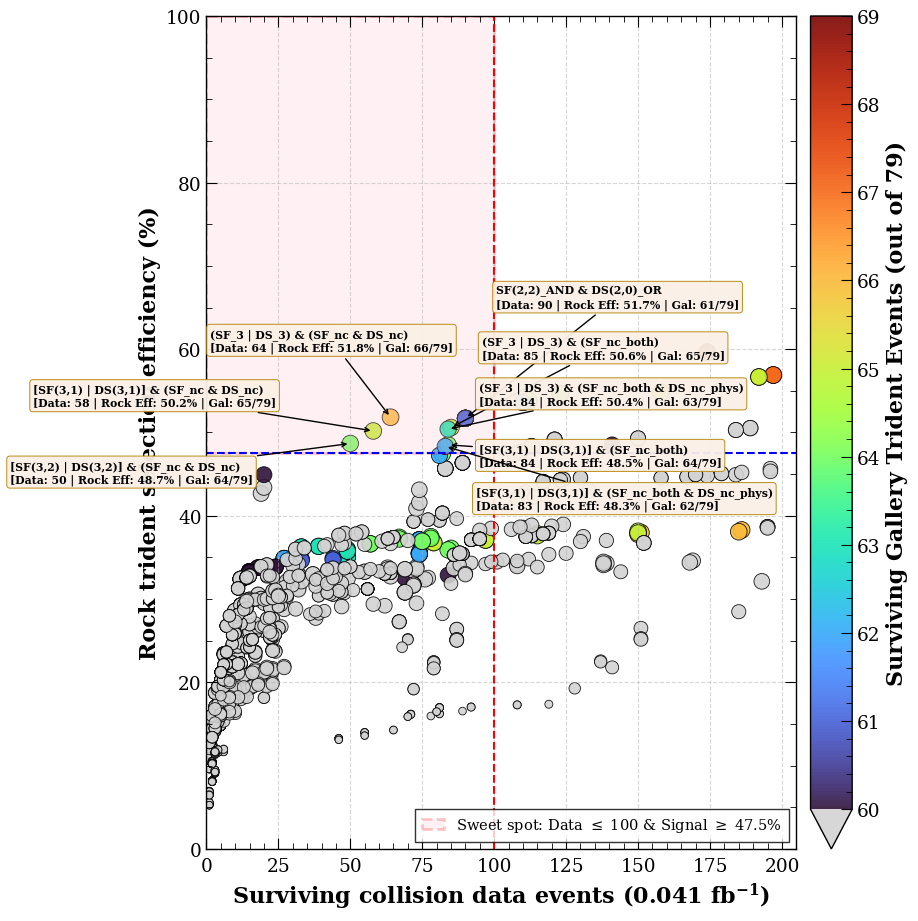

In [31]:
OUT_PARQUET = Path("topological_criteria_scan_unified.parquet")
OUT_PLOT_DIR = Path("plots")
OUT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

df_unified = pd.read_parquet(OUT_PARQUET)


# ==============================================================================
# 2. LABEL PARSER
# ==============================================================================
def format_intuitive_label(lbl: str) -> str:
    """Converts technical tuple strings into clean, readable physics expressions."""
    try:
        parts = ast.literal_eval(lbl)
    except (ValueError, SyntaxError, TypeError):
        return lbl

    mode = parts[0]

    if mode == "FACTORIZED_OR_AND":
        n1, n2 = parts[1]
        csf, cds = parts[2]
        m_str = (
            f"[SF({n1},{n2}) | DS({n1},{n2})]"
            if (n1, n2) != (3, 0)
            else "(SF_3 | DS_3)"
        )

        if csf == "OR" and cds == "OR":
            c_str = "(SF_nc & DS_nc)"
        elif csf == "AND" and cds == "OFF":
            c_str = "(SF_nc_both)"
        elif csf == "AND" and cds == "OR_phys":
            c_str = "(SF_nc_both & DS_nc_phys)"
        elif csf == "OR" and cds == "OFF":
            c_str = "(SF_nc)"
        else:
            c_str = f"(SF:{csf} & DS:{cds})"

        return f"{m_str} & {c_str}"

    if mode == "SF_ONLY":
        sf_m = parts[1][:2]
        sf_c = parts[1][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} ONLY"

    if mode == "DS_ONLY":
        ds_m = parts[2][:2]
        ds_c = parts[2][2]
        return f"DS({ds_m[0]},{ds_m[1]})_{ds_c} ONLY"

    if mode == "AND":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} & DS({ds_m[0]},{ds_m[1]})_{ds_c}"

    if mode == "OR":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} OR DS({ds_m[0]},{ds_m[1]})_{ds_c}"

    return lbl


# ==============================================================================
# 3. FILTERING & SWEET-SPOT SELECTION
# ==============================================================================
df_unified["clean_label"] = df_unified["label"].apply(format_intuitive_label)

df_zoom = df_unified[
    (df_unified["data_events"] > 0) & (df_unified["data_events"] <= 200)
].copy()

df_ul = df_zoom[
    (df_zoom["data_events"] <= 100) & (df_zoom["rock_eff_pct"] >= 47.5)
].sort_values(by=["rock_eff_pct", "gallery_events"], ascending=[False, False])

unique_ul_dict = {}
for _, r in df_ul.iterrows():
    key = (r["data_events"], round(r["rock_eff_pct"], 1))
    if key not in unique_ul_dict:
        unique_ul_dict[key] = r

# ==============================================================================
# 4. SCATTER PLOT
# ==============================================================================
custom_cmap = mpl.colormaps["turbo"].copy()
custom_cmap.set_under("lightgray")

fig, ax = plt.subplots(figsize=(9.5, 9.5))
max_gallery = df_zoom["gallery_events"].max()

sc = ax.scatter(
    df_zoom["data_events"],
    df_zoom["rock_eff_pct"],
    c=df_zoom["gallery_events"],
    s=df_zoom["gallery_events"] * 2.2,
    cmap=custom_cmap,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.6,
    vmin=60,
    vmax=max_gallery,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, extend="min")
cbar.set_label(
    "Surviving Gallery Trident Events (out of 79)",
    fontweight="bold",
)

ax.set_xlabel(
    r"Surviving collision data events (0.041 fb$^{-1}$)",
    fontweight="bold",
)
ax.set_ylabel(
    "Rock trident selection efficiency (%)",
    fontweight="bold",
)
ax.grid(True, linestyle="--", alpha=0.5)

# Highlight sweet spot region
ul_box = patches.Rectangle(
    (0, 47.5),
    100,
    52.5,
    linewidth=2,
    edgecolor="red",
    facecolor="pink",
    alpha=0.22,
    linestyle="--",
    label=r"Sweet spot: Data $\leq$ 100 & Signal $\geq$ 47.5%",
)
ax.add_patch(ul_box)

ax.set_xlim(0, 205)
ax.set_ylim(0, 100)
ax.axvline(100, color="red", linestyle="--", linewidth=1.5)
ax.axhline(47.5, color="blue", linestyle="--", linewidth=1.5)
ax.legend(loc="lower right", fontsize=10.5)

# ==============================================================================
# 5. SWEET-SPOT ANNOTATIONS
# ==============================================================================
custom_offsets = {
    (50, 48.7): (-245, -28),
    (58, 50.2): (-245, 18),
    (64, 51.8): (-130, 48),
    (83, 48.3): (22, -45),
    (84, 48.5): (22, -15),
    (84, 50.4): (22, 18),
    (85, 50.6): (22, 50),
    (90, 51.7): (22, 80),
}

for (x_val, y_val), r in unique_ul_dict.items():
    ox, oy = custom_offsets.get(
        (r["data_events"], round(r["rock_eff_pct"], 1)), (20, 20)
    )
    ann_text = (
        f"{r['clean_label']}\n"
        f"[Data: {r['data_events']} | Rock Eff: {r['rock_eff_pct']:.1f}% | "
        f"Gal: {r['gallery_events']}/79]"
    )
    ax.annotate(
        ann_text,
        xy=(r["data_events"], r["rock_eff_pct"]),
        xytext=(ox, oy),
        textcoords="offset points",
        fontsize=7.8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="linen",
            alpha=0.95,
            edgecolor="darkgoldenrod",
            linewidth=0.7,
        ),
        arrowprops=dict(arrowstyle="->", lw=1.0, color="black"),
    )

plt.tight_layout()
plt.savefig(OUT_PLOT_DIR / "sweet_spot_linear_plot.png")
plt.show()

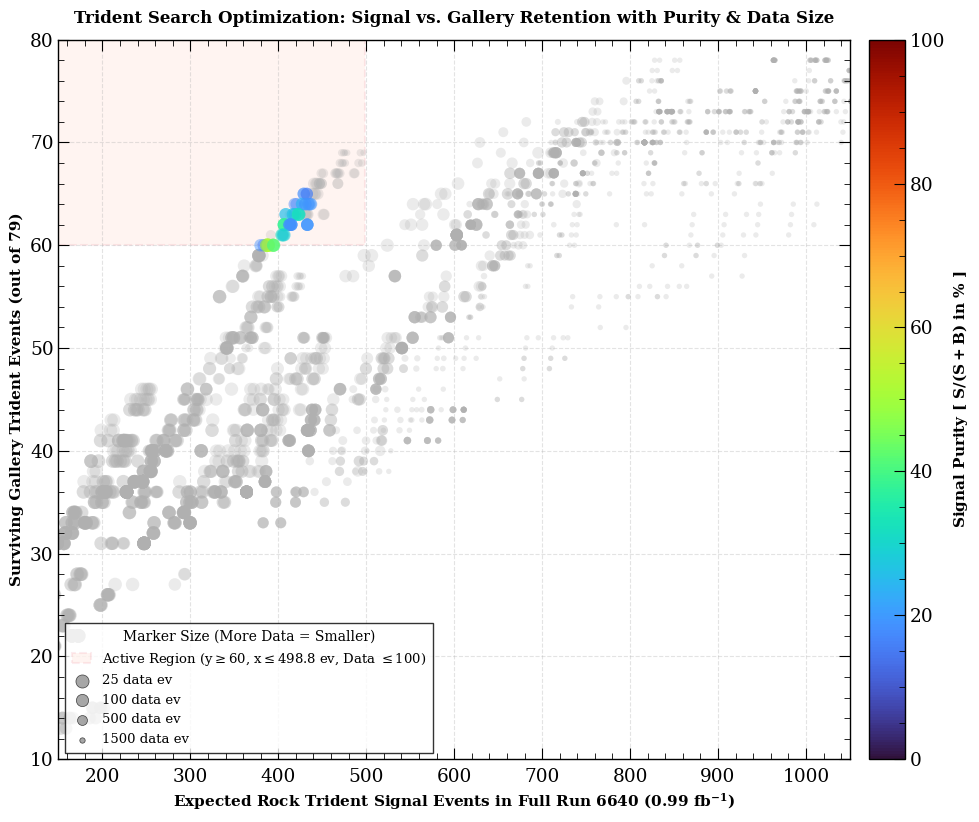

In [35]:
DATA_PATH = Path("topological_criteria_scan_unified.parquet")
df = pd.read_parquet(DATA_PATH)

LUMI_SUB_DATA = 0.040777061918046364
LUMI_FULL_6640 = 0.9915864253712848
SCALE_SUB_TO_FULL = LUMI_FULL_6640 / LUMI_SUB_DATA

# Expected background in Full Run 6640
df["bkg_full_6640"] = df["data_events"] * SCALE_SUB_TO_FULL
s = df["signal_full_6640"]
b = df["bkg_full_6640"]

# Signal Purity / Fraction: S / (S + B) in %
df["purity_pct"] = (s / (s + b)) * 100.0


def format_intuitive_label(lbl: str) -> str:
    """Converts technical tuple strings into clean, readable physics expressions."""
    try:
        parts = ast.literal_eval(lbl)
    except (ValueError, SyntaxError, TypeError):
        return lbl

    mode = parts[0]

    if mode == "FACTORIZED_OR_AND":
        n1, n2 = parts[1]
        csf, cds = parts[2]
        m_str = (
            f"[SF({n1},{n2}) | DS({n1},{n2})]"
            if (n1, n2) != (3, 0)
            else "(SF_3 | DS_3)"
        )

        if csf == "OR" and cds == "OR":
            c_str = "(SF_nc & DS_nc)"
        elif csf == "AND" and cds == "OFF":
            c_str = "(SF_nc_both)"
        elif csf == "AND" and cds == "OR_phys":
            c_str = "(SF_nc_both & DS_nc_phys)"
        elif csf == "OR" and cds == "OFF":
            c_str = "(SF_nc)"
        else:
            c_str = f"(SF:{csf} & DS:{cds})"

        return f"{m_str} & {c_str}"

    if mode == "SF_ONLY":
        sf_m = parts[1][:2]
        sf_c = parts[1][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} ONLY"

    if mode == "DS_ONLY":
        ds_m = parts[2][:2]
        ds_c = parts[2][2]
        return f"DS({ds_m[0]},{ds_m[1]})_{ds_c} ONLY"

    if mode == "AND":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} & DS({ds_m[0]},{ds_m[1]})_{ds_c}"

    if mode == "OR":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} OR DS({ds_m[0]},{ds_m[1]})_{ds_c}"

    return lbl


df["clean_label"] = df["label"].apply(format_intuitive_label)

# Filter for active points
df_plot = df[
    (df["gallery_events"] >= 10) & (df["signal_full_6640"] > 100)
].copy()

# ==============================================================================
# 2. INVERSE MARKER SIZE SCALING & SWEET SPOT FILTERING
# ==============================================================================
s_max, s_min = 100, 15  # Large for low background, small for high background
d_clip = np.clip(df_plot["data_events"].to_numpy(), 0, 1500)

# Inverse square-root scaling (More Data Events -> Smaller Marker)
df_plot["marker_size"] = s_max - (np.sqrt(d_clip) / np.sqrt(1500)) * (
    s_max - s_min
)

# Selection criteria for annotation candidates
df_sweet = df_plot[
    (df_plot["data_events"] <= 100) & (df_plot["rock_eff_pct"] >= 47.5)
].sort_values(by=["gallery_events", "purity_pct"], ascending=[False, False])

unique_sweet = {}
for _, r in df_sweet.iterrows():
    key = (r["data_events"], round(r["rock_eff_pct"], 1))
    if key not in unique_sweet:
        unique_sweet[key] = r

# ==============================================================================
# 3. REGION PARTITIONING (ACTIVE BOX & BACKGROUND FILTERS)
# ==============================================================================
x_lim_max = 1050.0
x_box_cutoff = 0.475 * x_lim_max  # 498.75
y_box_min = 60.0

# Mask for points within target box and satisfying the data size threshold
in_active_box = (
    (df_plot["gallery_events"] >= y_box_min)
    & (df_plot["signal_full_6640"] <= x_box_cutoff)
    & (df_plot["data_events"] <= 100)
)

df_active = df_plot[in_active_box]
df_grey = df_plot[~in_active_box]

# Split active points into background and labeled subsets
sweet_indices = [
    r.name for r in unique_sweet.values() if r.name in df_active.index
]
df_active_bg = df_active.drop(index=sweet_indices)
df_highlight = df_active.loc[sweet_indices]

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
fig, ax = plt.subplots(figsize=(10.5, 8.5))

# Layer 1: Inactive / Filtered-out points (Greyed out)
ax.scatter(
    df_grey["signal_full_6640"],
    df_grey["gallery_events"],
    s=df_grey["marker_size"],
    color="#B0B0B0",
    alpha=0.25,
    edgecolor="none",
    zorder=1,
)

# Layer 2: Active box points not in top annotations (Transparent colormap)
ax.scatter(
    df_active_bg["signal_full_6640"],
    df_active_bg["gallery_events"],
    c=df_active_bg["purity_pct"],
    s=df_active_bg["marker_size"],
    cmap="turbo",
    alpha=0.45,
    edgecolor="none",
    vmin=0,
    vmax=100,
    zorder=2,
)

# Layer 3: Highlighted annotated points (Solid, emphasized)
sc_highlight = ax.scatter(
    df_highlight["signal_full_6640"],
    df_highlight["gallery_events"],
    c=df_highlight["purity_pct"],
    s=df_highlight["marker_size"] * 1.3,
    cmap="turbo",
    alpha=1.0,
    edgecolor="black",
    linewidth=1.2,
    vmin=0,
    vmax=100,
    zorder=5,
)

# Draw the boundary rectangle for the active region
active_box_patch = patches.Rectangle(
    (150, y_box_min),
    x_box_cutoff - 150,
    80 - y_box_min,
    linewidth=1.5,
    edgecolor="crimson",
    facecolor="coral",
    alpha=0.08,
    linestyle="--",
    label=rf"Active Region ($y \geq 60$, $x \leq {x_box_cutoff:.1f}$ ev, Data $\leq 100$)",
    zorder=0,
)
ax.add_patch(active_box_patch)

# Colorbar
cbar = fig.colorbar(sc_highlight, ax=ax, pad=0.02)
cbar.set_label(
    r"Signal Purity [ $S / (S + B)$ in % ]",
    fontweight="bold",
    fontsize=11,
)

ax.set_xlabel(
    r"Expected Rock Trident Signal Events in Full Run 6640 (0.99 fb$^{-1}$)",
    fontweight="bold",
    fontsize=11,
)
ax.set_ylabel(
    "Surviving Gallery Trident Events (out of 79)",
    fontweight="bold",
    fontsize=11,
)
ax.set_title(
    "Trident Search Optimization: Signal vs. Gallery Retention with Purity &"
    " Data Size",
    fontweight="bold",
    fontsize=12,
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.35)

ax.set_xlim(150, x_lim_max)
ax.set_ylim(10, 80)

# ==============================================================================
# 5. MARKER SIZE LEGEND
# ==============================================================================
for d_example in [25, 100, 500, 1500]:
    sz = s_max - (np.sqrt(min(d_example, 1500)) / np.sqrt(1500)) * (
        s_max - s_min
    )
    ax.scatter(
        [],
        [],
        s=sz,
        c="gray",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.5,
        label=f"{d_example} data ev",
    )

ax.legend(
    scatterpoints=1,
    loc="lower left",
    fontsize=9.5,
    title="Marker Size (More Data = Smaller)",
    title_fontsize=10,
)

# ==============================================================================
# 6. ANNOTATIONS
# ==============================================================================
offsets = [
    (35, 25),
    (-260, 20),
    (-260, -35),
    (35, -30),
    (-180, 45),
]

for idx, (_, r) in enumerate(df_highlight.iterrows()):
    ox, oy = offsets[idx % len(offsets)]

    ann_text = (
        f"{r['clean_label']}\n"
        f"S: {r['signal_full_6640']:.1f} | Gal: {r['gallery_events']}/79 | "
        f"Data: {r['data_events']} (Pur: {r['purity_pct']:.1f}%)"
    )

    ax.annotate(
        ann_text,
        xy=(r["signal_full_6640"], r["gallery_events"]),
        xytext=(ox, oy),
        textcoords="offset points",
        fontsize=7.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="linen",
            alpha=0.85,
            edgecolor="darkgoldenrod",
            linewidth=0.6,
        ),
        arrowprops=dict(
            arrowstyle="->",
            lw=0.8,
            color="black",
            connectionstyle="angle,angleA=0,angleB=90,rad=3",
        ),
        zorder=6,
    )

plt.tight_layout()
plt.show()

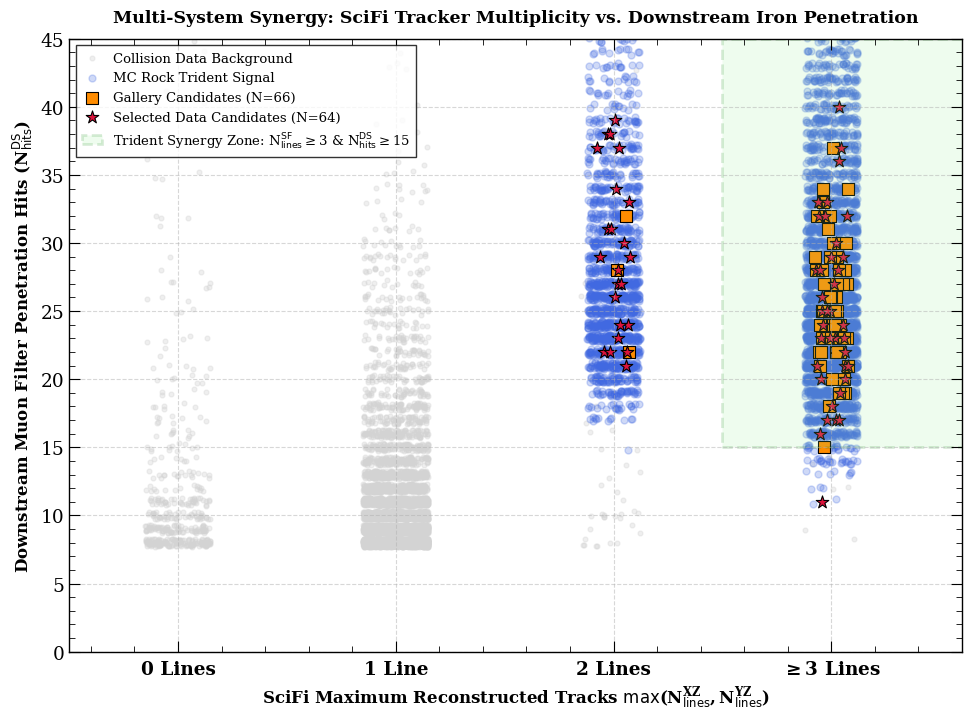

In [39]:
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. PATHS & DATA LOADING
# ==============================================================================
BASE_PATH = Path("/eos/user/i/idioniso/sndMuTri/data")
MC_PATH = (
    BASE_PATH / "trimuon_boost100_looseCuts7/trimuon_boost100_looseCuts7.parquet"
)
DATA_PATH = BASE_PATH / "run_006640/run6640_looseCuts7_hough.parquet"
GALLERY_PATH = (
    BASE_PATH
    / "gallery_looseCuts7/mu3_search_hough_looseCuts7_combined.parquet"
)

# mc_df = pd.read_parquet(MC_PATH)
# data = pd.read_parquet(DATA_PATH)
# gallery = pd.read_parquet(GALLERY_PATH)
# gallery_6640 = gallery[gallery["run_id"] == 6640].copy()

# Filter for Rock Trident MC Signal
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)].copy()


# ==============================================================================
# 2. SELECTION ALGORITHM
# ==============================================================================
def apply_optimal_selection(df: pd.DataFrame) -> pd.DataFrame:
    """Applies [SF(3,0) | DS(3,0)] & (SF_nc & DS_nc) selection."""

    def check_nc(
        prefix: str, proj: str, z_min: float, z_max: float
    ) -> np.ndarray:
        n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
        m1, c1 = (
            df[f"{proj}_{prefix}_m1"].to_numpy(),
            df[f"{proj}_{prefix}_c1"].to_numpy(),
        )
        m2, c2 = (
            df[f"{proj}_{prefix}_m2"].to_numpy(),
            df[f"{proj}_{prefix}_c2"].to_numpy(),
        )
        m3, c3 = (
            df[f"{proj}_{prefix}_m3"].to_numpy(),
            df[f"{proj}_{prefix}_c3"].to_numpy(),
        )

        x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
        x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
        x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3

        no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
        no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
        no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0

        pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
        pass_2 = (n == 2) & no_cross_12
        return pass_3 | pass_2

    m_sf_xz = df["n_lines_sf_xz"] >= 3
    m_sf_yz = df["n_lines_sf_yz"] >= 3
    m_ds_xz = df["n_lines_ds_xz"] >= 3
    m_ds_yz = df["n_lines_ds_yz"] >= 3
    mult_mask = (m_sf_xz | m_sf_yz | m_ds_xz | m_ds_yz).to_numpy()

    coll_sf = check_nc("sf", "xz", 260.0, 355.0) | check_nc(
        "sf", "yz", 260.0, 355.0
    )
    coll_ds = check_nc("ds", "xz", 460.0, 590.0) | check_nc(
        "ds", "yz", 460.0, 590.0
    )

    return df[mult_mask & coll_sf & coll_ds].copy()


sel_data = apply_optimal_selection(data)
sel_mc = apply_optimal_selection(sig_mc)
sel_gal = apply_optimal_selection(gallery_6640)

# ==============================================================================
# 3. PLOT: MULTI-SYSTEM SYNERGY
# ==============================================================================
data_max_sf = np.maximum(data["n_lines_sf_xz"], data["n_lines_sf_yz"])
mc_max_sf = np.maximum(sel_mc["n_lines_sf_xz"], sel_mc["n_lines_sf_yz"])
gal_max_sf = np.maximum(sel_gal["n_lines_sf_xz"], sel_gal["n_lines_sf_yz"])
cand_max_sf = np.maximum(sel_data["n_lines_sf_xz"], sel_data["n_lines_sf_yz"])

fig2, ax2 = plt.subplots(figsize=(10, 7.5))

# Layer 1: Background Data (Faint background density)
ax2.scatter(
    data_max_sf.sample(n=min(6000, len(data)), random_state=42)
    + np.random.uniform(-0.15, 0.15, min(6000, len(data))),
    data["ds_nhits"].sample(n=min(6000, len(data)), random_state=42)
    + np.random.uniform(-0.3, 0.3, min(6000, len(data))),
    c="lightgray",
    s=12,
    alpha=0.35,
    label="Collision Data Background",
)

# Layer 2: MC Signal Density
ax2.scatter(
    mc_max_sf + np.random.uniform(-0.12, 0.12, len(mc_max_sf)),
    sel_mc["ds_nhits"] + np.random.uniform(-0.25, 0.25, len(mc_max_sf)),
    c="royalblue",
    s=25,
    alpha=0.25,
    label="MC Rock Trident Signal",
)

# Layer 3: Surviving Gallery Candidates
ax2.scatter(
    gal_max_sf + np.random.uniform(-0.08, 0.08, len(gal_max_sf)),
    sel_gal["ds_nhits"],
    c="darkorange",
    s=65,
    marker="s",
    edgecolor="black",
    linewidth=0.8,
    label=f"Gallery Candidates (N={len(sel_gal)})",
)

# Layer 4: Selected Data Candidates
ax2.scatter(
    cand_max_sf + np.random.uniform(-0.08, 0.08, len(cand_max_sf)),
    sel_data["ds_nhits"],
    c="crimson",
    s=90,
    marker="*",
    edgecolor="black",
    linewidth=0.8,
    label=f"Selected Data Candidates (N={len(sel_data)})",
)

# Highlight Trident Golden Synergy Quadrant
golden_quadrant = patches.Rectangle(
    (2.5, 15),
    1.2,
    30,
    linewidth=2,
    edgecolor="green",
    facecolor="lightgreen",
    alpha=0.15,
    linestyle="--",
    label=(
        r"Trident Synergy Zone: $N_{\mathrm{lines}}^{\mathrm{SF}} \geq 3$"
        r" & $N_{\mathrm{hits}}^{\mathrm{DS}} \geq 15$"
    ),
)
ax2.add_patch(golden_quadrant)

ax2.set_xlabel(
    r"SciFi Maximum Reconstructed Tracks $\max(N_{\mathrm{lines}}^{XZ},"
    r" N_{\mathrm{lines}}^{YZ})$",
    fontsize=12,
    fontweight="bold",
)
ax2.set_ylabel(
    r"Downstream Muon Filter Penetration Hits ($N_{\mathrm{hits}}^{\mathrm{DS}}$)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_title(
    "Multi-System Synergy: SciFi Tracker Multiplicity vs. Downstream Iron"
    " Penetration",
    fontsize=12.5,
    fontweight="bold",
    pad=12,
)
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(
    ["0 Lines", "1 Line", "2 Lines", r"$\geq 3$ Lines"], fontweight="bold"
)
ax2.set_xlim(-0.5, 3.6)
ax2.set_ylim(0, 45)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", fontsize=9.5)

plt.tight_layout()
plt.show()

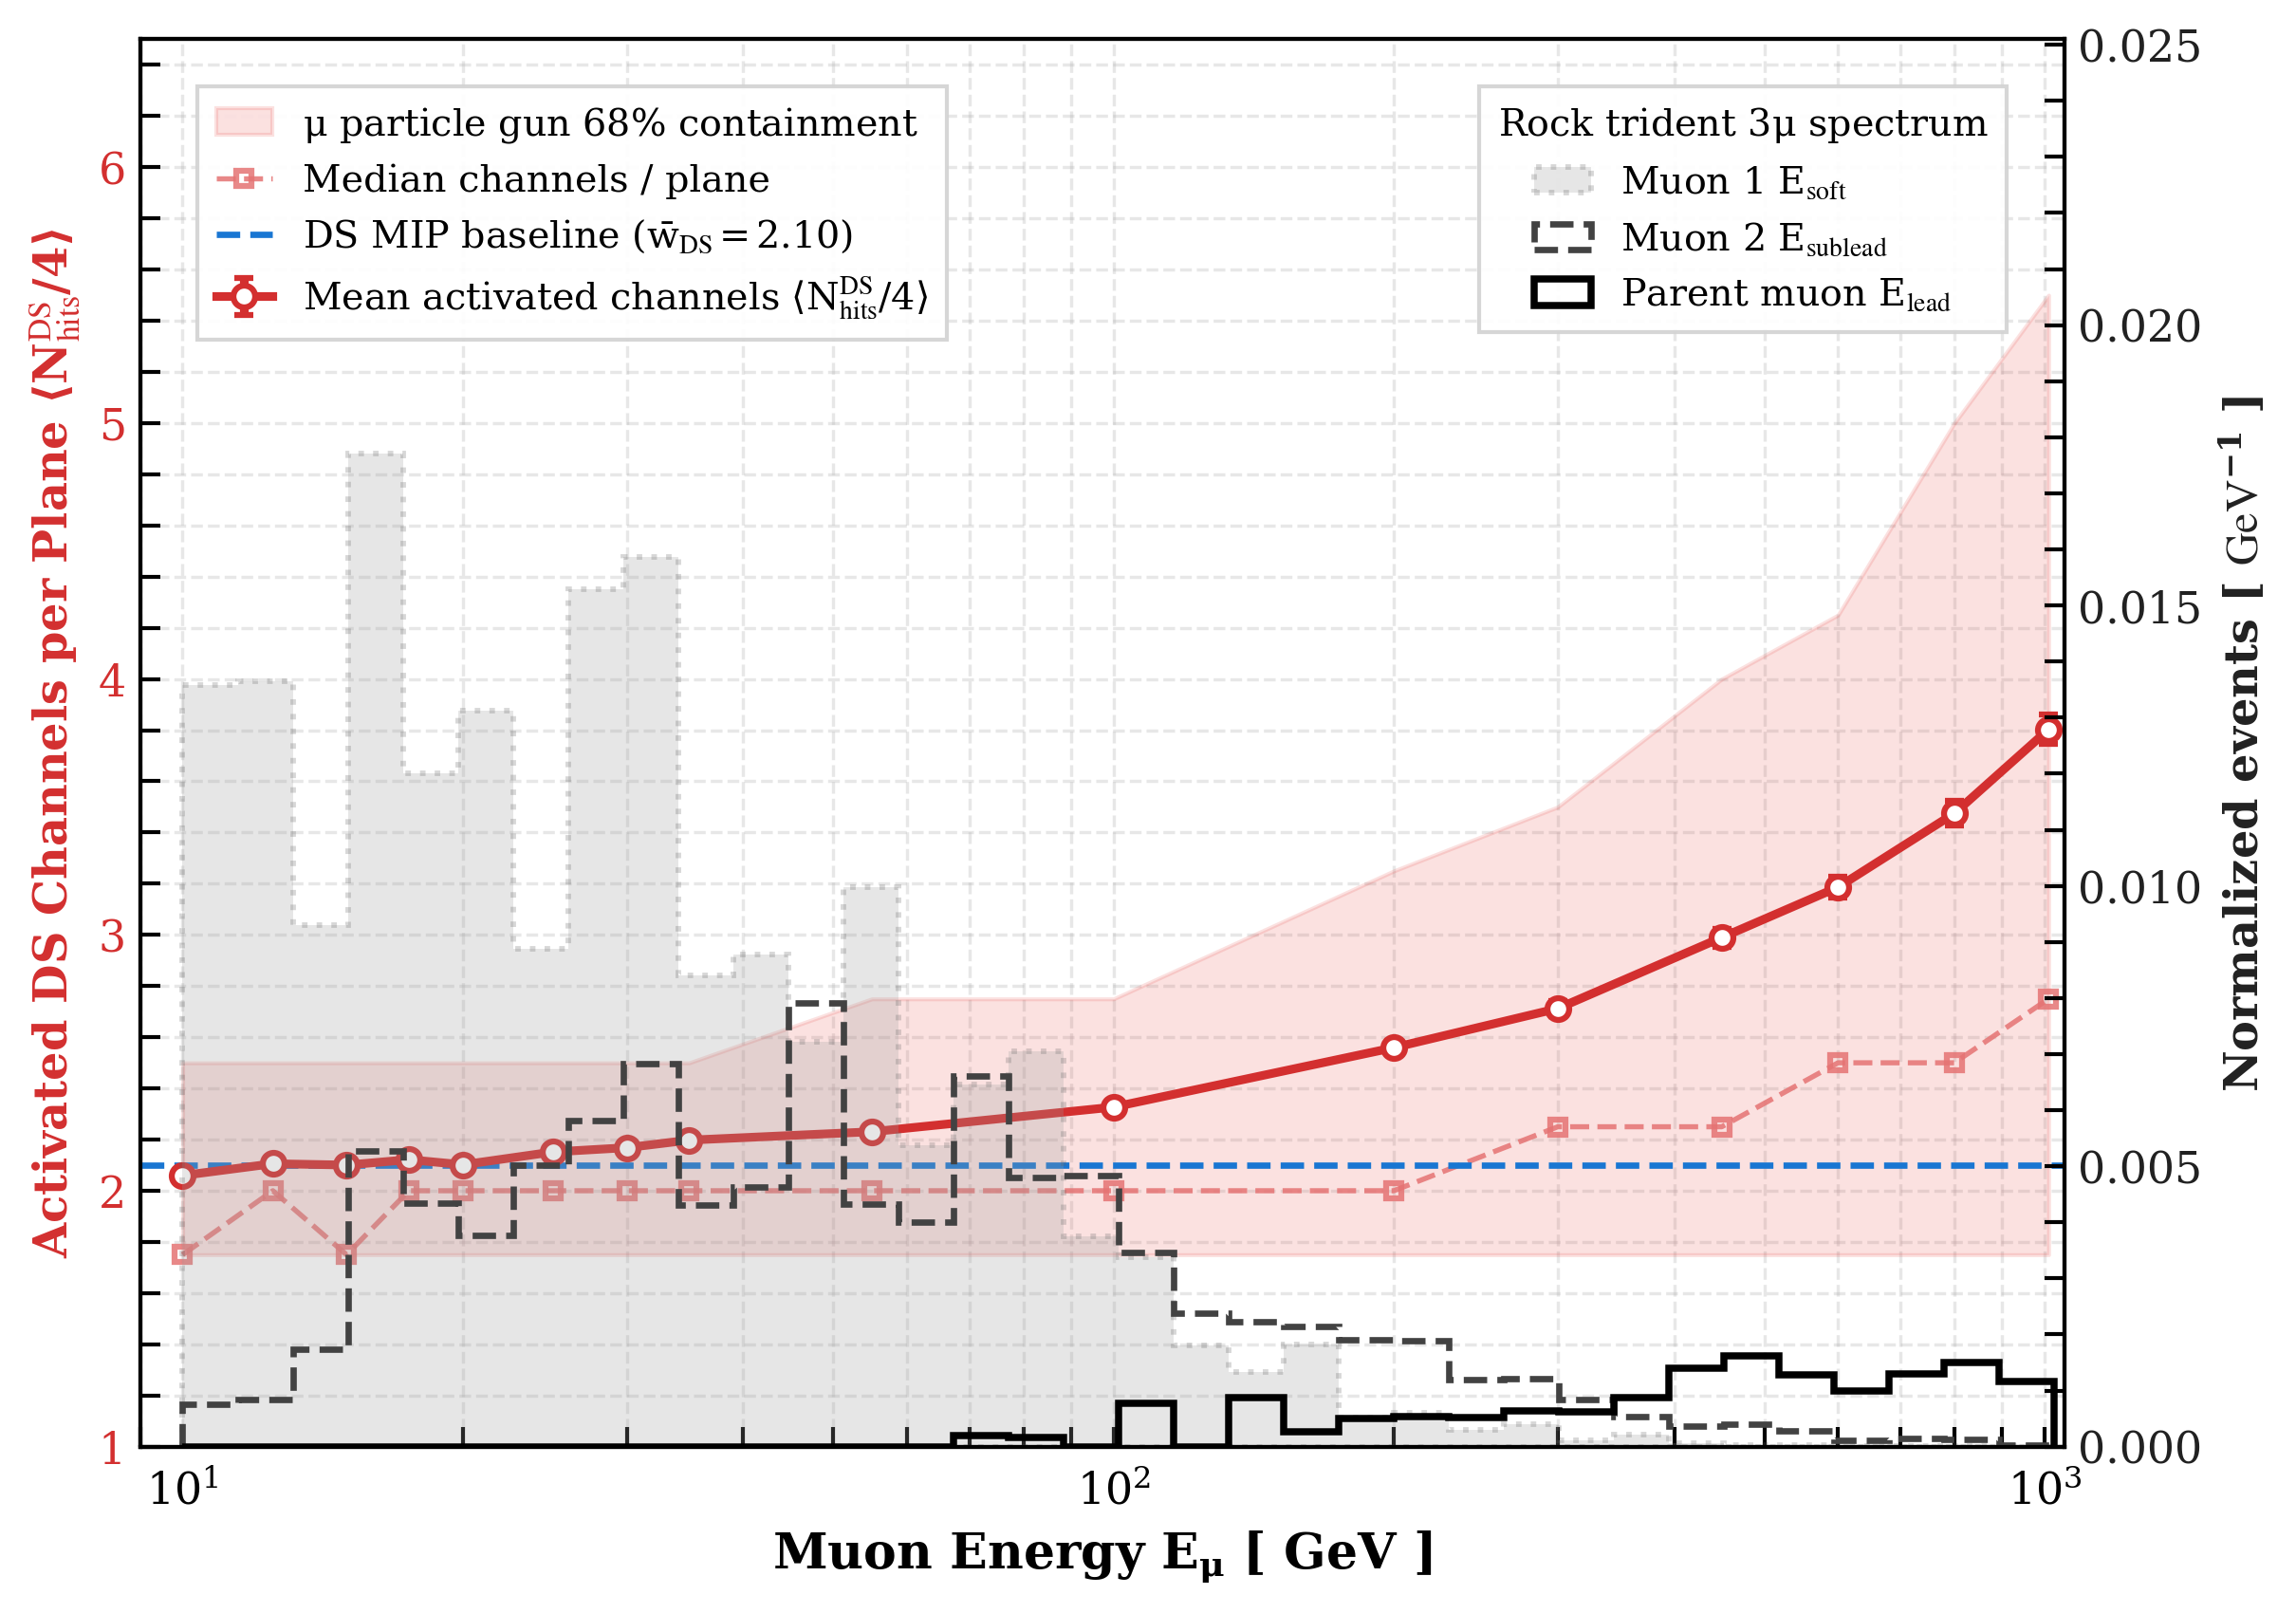

In [72]:
    from pathlib import Path
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    import pandas as pd
    import ROOT
    
    ROOT.gROOT.SetBatch(True)
    
    # ==============================================================================
    # 1. SCAN PARTICLE GUN ENERGY DIRECTORIES FOR DOWNSTREAM (DS, System 3)
    # ==============================================================================
    PGUN_DIR = Path("/eos/user/i/idioniso/1_Data/Monte_Carlo/pGun/muons")
    energy_dirs = [
        "10.GeV",
        "12.5.GeV",
        "15.GeV",
        "17.5.GeV",
        "20.GeV",
        "25.GeV",
        "30.GeV",
        "35.GeV",
        "55.GeV",
        "100.GeV",
        "200.GeV",
        "300.GeV",
        "450.GeV",
        "600.GeV",
        "800.GeV",
        "1010.GeV",
    ]
    
    results_ds = []
    
    for edir in energy_dirs:
      dir_path = PGUN_DIR / edir
      digi_file = dir_path / "sndLHC.PG_13-TGeant4_digCPP.root"
      if not digi_file.exists():
        continue
    
      energy_val = float(edir.replace(".GeV", "").replace("GeV", ""))
      f = ROOT.TFile.Open(str(digi_file))
      if not f or f.IsZombie():
        continue
    
      tree = f.Get("cbmsim")
      if not tree:
        f.Close()
        continue
    
      n_entries = min(4000, tree.GetEntries())
      hit_counts_ds = []
    
      for i in range(n_entries):
        tree.GetEntry(i)
        # Count Downstream hits (System == 3)
        n_ds = sum(1 for h in tree.Digi_MuFilterHits if h.GetSystem() == 3)
        if n_ds >= 2:  # Muon reached DS
          hit_counts_ds.append(n_ds)
    
      f.Close()
    
      if len(hit_counts_ds) > 0:
        arr = np.array(hit_counts_ds)
        mean_val = float(np.mean(arr))
        median_val = float(np.median(arr))
        sem_val = float(np.std(arr) / np.sqrt(len(arr)))
        q16 = float(np.percentile(arr, 16))
        q84 = float(np.percentile(arr, 84))
    
        # 4 DS tracking planes (DS1H, DS1V, DS2H, DS2V)
        results_ds.append({
            "energy_gev": energy_val,
            "mean_total_hits": mean_val,
            "median_total_hits": median_val,
            "sem_total_hits": sem_val,
            "q16_total_hits": q16,
            "q84_total_hits": q84,
            "mean_per_plane": mean_val / 4.0,
            "sem_per_plane": sem_val / 4.0,
            "median_per_plane": median_val / 4.0,
            "q16_per_plane": q16 / 4.0,
            "q84_per_plane": q84 / 4.0,
            "n_events": len(arr),
        })
    
    df_pgun_ds = pd.DataFrame(results_ds).sort_values(by="energy_gev")
    
    # ==============================================================================
    # 2. EXTRACT POST-SELECTION TRIDENT MUON ENERGIES FROM MC
    # ==============================================================================
    MC_PATH = Path(
        "/eos/user/i/idioniso/sndMuTri/data/trimuon_boost100_looseCuts7/trimuon_boost100_looseCuts7.parquet"
    )
    mc_df = pd.read_parquet(MC_PATH)
    sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)].copy()
    
    
    def apply_optimal_selection(df: pd.DataFrame) -> pd.DataFrame:
      """Applies [SF(3,0) | DS(3,0)] & (SF_nc & DS_nc) selection."""
    
      def check_nc(prefix, proj, z_min, z_max):
        n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
        m1, c1 = df[f"{proj}_{prefix}_m1"].to_numpy(), df[
            f"{proj}_{prefix}_c1"
        ].to_numpy()
        m2, c2 = df[f"{proj}_{prefix}_m2"].to_numpy(), df[
            f"{proj}_{prefix}_c2"
        ].to_numpy()
        m3, c3 = df[f"{proj}_{prefix}_m3"].to_numpy(), df[
            f"{proj}_{prefix}_c3"
        ].to_numpy()
        x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
        x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
        x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3
        no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
        no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
        no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0
        pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
        pass_2 = (n == 2) & no_cross_12
        return pass_3 | pass_2
    
      m_sf_xz = df["n_lines_sf_xz"] >= 3
      m_sf_yz = df["n_lines_sf_yz"] >= 3
      m_ds_xz = df["n_lines_ds_xz"] >= 3
      m_ds_yz = df["n_lines_ds_yz"] >= 3
      mult_mask = (m_sf_xz | m_sf_yz | m_ds_xz | m_ds_yz).to_numpy()
    
      coll_sf = check_nc("sf", "xz", 260.0, 355.0) | check_nc(
          "sf", "yz", 260.0, 355.0
      )
      coll_ds = check_nc("ds", "xz", 460.0, 590.0) | check_nc(
          "ds", "yz", 460.0, 590.0
      )
      return df[mult_mask & coll_sf & coll_ds].copy()
    
    
    sel_mc = apply_optimal_selection(sig_mc)
    
    # Compute individual muon energies
    m_mu = 0.10566
    e1 = np.sqrt(sel_mc["p_mu_in"] ** 2 + m_mu**2).to_numpy()
    e2 = np.sqrt(sel_mc["p_mu_minus"] ** 2 + m_mu**2).to_numpy()
    e3 = np.sqrt(sel_mc["p_mu_plus"] ** 2 + m_mu**2).to_numpy()
    e_mat = np.sort(np.vstack([e1, e2, e3]).T, axis=1)
    
    e_soft = e_mat[:, 0]
    e_sublead = e_mat[:, 1]
    e_lead = e_mat[:, 2]
    w_mc = sel_mc["mc_weight"].to_numpy()
    
    # ==============================================================================
    # 3. PUBLICATION-QUALITY DOWNSTREAM (DS) RESPONSE & ENERGY SPECTRUM PLOT
    # ==============================================================================
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12.5,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9.5,
    })
    
    fig, ax1 = plt.subplots(figsize=(8.2, 5.8), dpi=300)
    bins_energy = np.logspace(1.0, 3.01, 35)  # 10 GeV to ~1010 GeV
    
    # ------------------------------------------------------------------------------
    # 1. RIGHT AXIS (Background): Post-Selection Trident Muon Energy Hierarchy
    # ------------------------------------------------------------------------------
    ax1_twin = ax1.twinx()
    
    # Softest Muon
    ax1_twin.hist(
        e_soft,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="stepfilled",
        facecolor="#9E9E9E",
        alpha=0.25,
        edgecolor="#616161",
        linestyle=":",
        linewidth=1.4,
        zorder=1,
        label=r"Muon 1 $E_{\mathrm{soft}}$",
    )
    
    # Sub-Leading Muon
    ax1_twin.hist(
        e_sublead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="#424242",
        linestyle="--",
        linewidth=1.6,
        zorder=2,
        label=r"Muon 2 $E_{\mathrm{sublead}}$",
    )
    
    # Leading Muon
    ax1_twin.hist(
        e_lead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=3,
        label=r"Parent muon $E_{\mathrm{lead}}$",
    )
    
    ax1_twin.set_ylabel(
        r"Normalized events [ $\mathrm{GeV}^{-1}$ ]",
        fontweight="bold",
        fontsize=11.5,
        color="#212121",
    )
    ax1_twin.tick_params(axis="y", labelcolor="#212121")
    ax1_twin.set_ylim(0, ax1_twin.get_ylim()[1] * 1.35)
    
    # ------------------------------------------------------------------------------
    # 2. LEFT AXIS (Foreground): Particle Gun DS Detector Response
    # ------------------------------------------------------------------------------
    # 68% containment interval band
    ax1.fill_between(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["q16_per_plane"],
        df_pgun_ds["q84_per_plane"],
        color="#E53935",
        alpha=0.15,
        zorder=4,
        label=r"$\mu$ particle gun $68\%$ containment",
    )
    
    # Subtle Median response (dashed, in background)
    ax1.plot(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["median_per_plane"],
        marker="s",
        markersize=3.8,
        markerfacecolor="none",
        markeredgecolor="#E57373",
        linestyle="--",
        color="#E57373",
        lw=1.3,
        alpha=0.85,
        zorder=5,
        label=r"Median channels / plane",
    )
    
    # Prominent Mean cluster size per plane
    ax1.errorbar(
        df_pgun_ds["energy_gev"],
        df_pgun_ds["mean_per_plane"],
        yerr=df_pgun_ds["sem_per_plane"],
        fmt="o-",
        color="#D32F2F",
        ecolor="#D32F2F",
        lw=2.2,
        markersize=5.5,
        capsize=2.5,
        zorder=7,
        label=r"Mean activated channels $\langle N_{\mathrm{hits}}^{\mathrm{DS}} / 4 \rangle$",
    )
    
    # DS MIP Plateau reference line (bar width ~ 1 cm -> w_DS ~ 2.10)
    ax1.axhline(
        2.10,
        color="#1976D2",
        linestyle="--",
        lw=1.6,
        zorder=6,
        label=r"DS MIP baseline ($\bar{w}_{\mathrm{DS}} = 2.10$)",
    )
    
    ax1.set_xscale("log")
    ax1.set_xlim(9, 1050)
    ax1.set_ylim(1.0, 6.5)  # Appropriately scaled for Downstream bar geometry
    
    ax1.set_xlabel(r"Muon Energy $E_{\mu}$ [ GeV ]", fontweight="bold")
    ax1.set_ylabel(
        r"Activated DS Channels per Plane $\langle N_{\mathrm{hits}}^{\mathrm{DS}} /"
        r" 4 \rangle$",
        fontweight="bold",
        fontsize=11.5,
        color="#D32F2F",
    )
    ax1.tick_params(axis="y", labelcolor="#D32F2F")

    # Minor tick formatters
    ax1.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto"))
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax1.tick_params(
        which="both", direction="in", top=False, right=False, length=5, width=1.0
    )
    ax1_twin.tick_params(
        which="both", direction="in", top=False, right=True, length=5, width=1.0
    )
    ax1.grid(True, which="both", linestyle="--", alpha=0.3)

    # ------------------------------------------------------------------------------
    # 3. SPLIT LEGENDS FOR READABILITY
    # ------------------------------------------------------------------------------
    # Left Legend: Detector Calibration / Particle Gun (DS)
    ax1.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title_fontsize=9.5,
    )

    # Right Legend: Trident Kinematics
    ax1_twin.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title=r"Rock trident $3\mu$ spectrum",
        title_fontsize=9.5,
    )

    plt.tight_layout()
    plt.show()

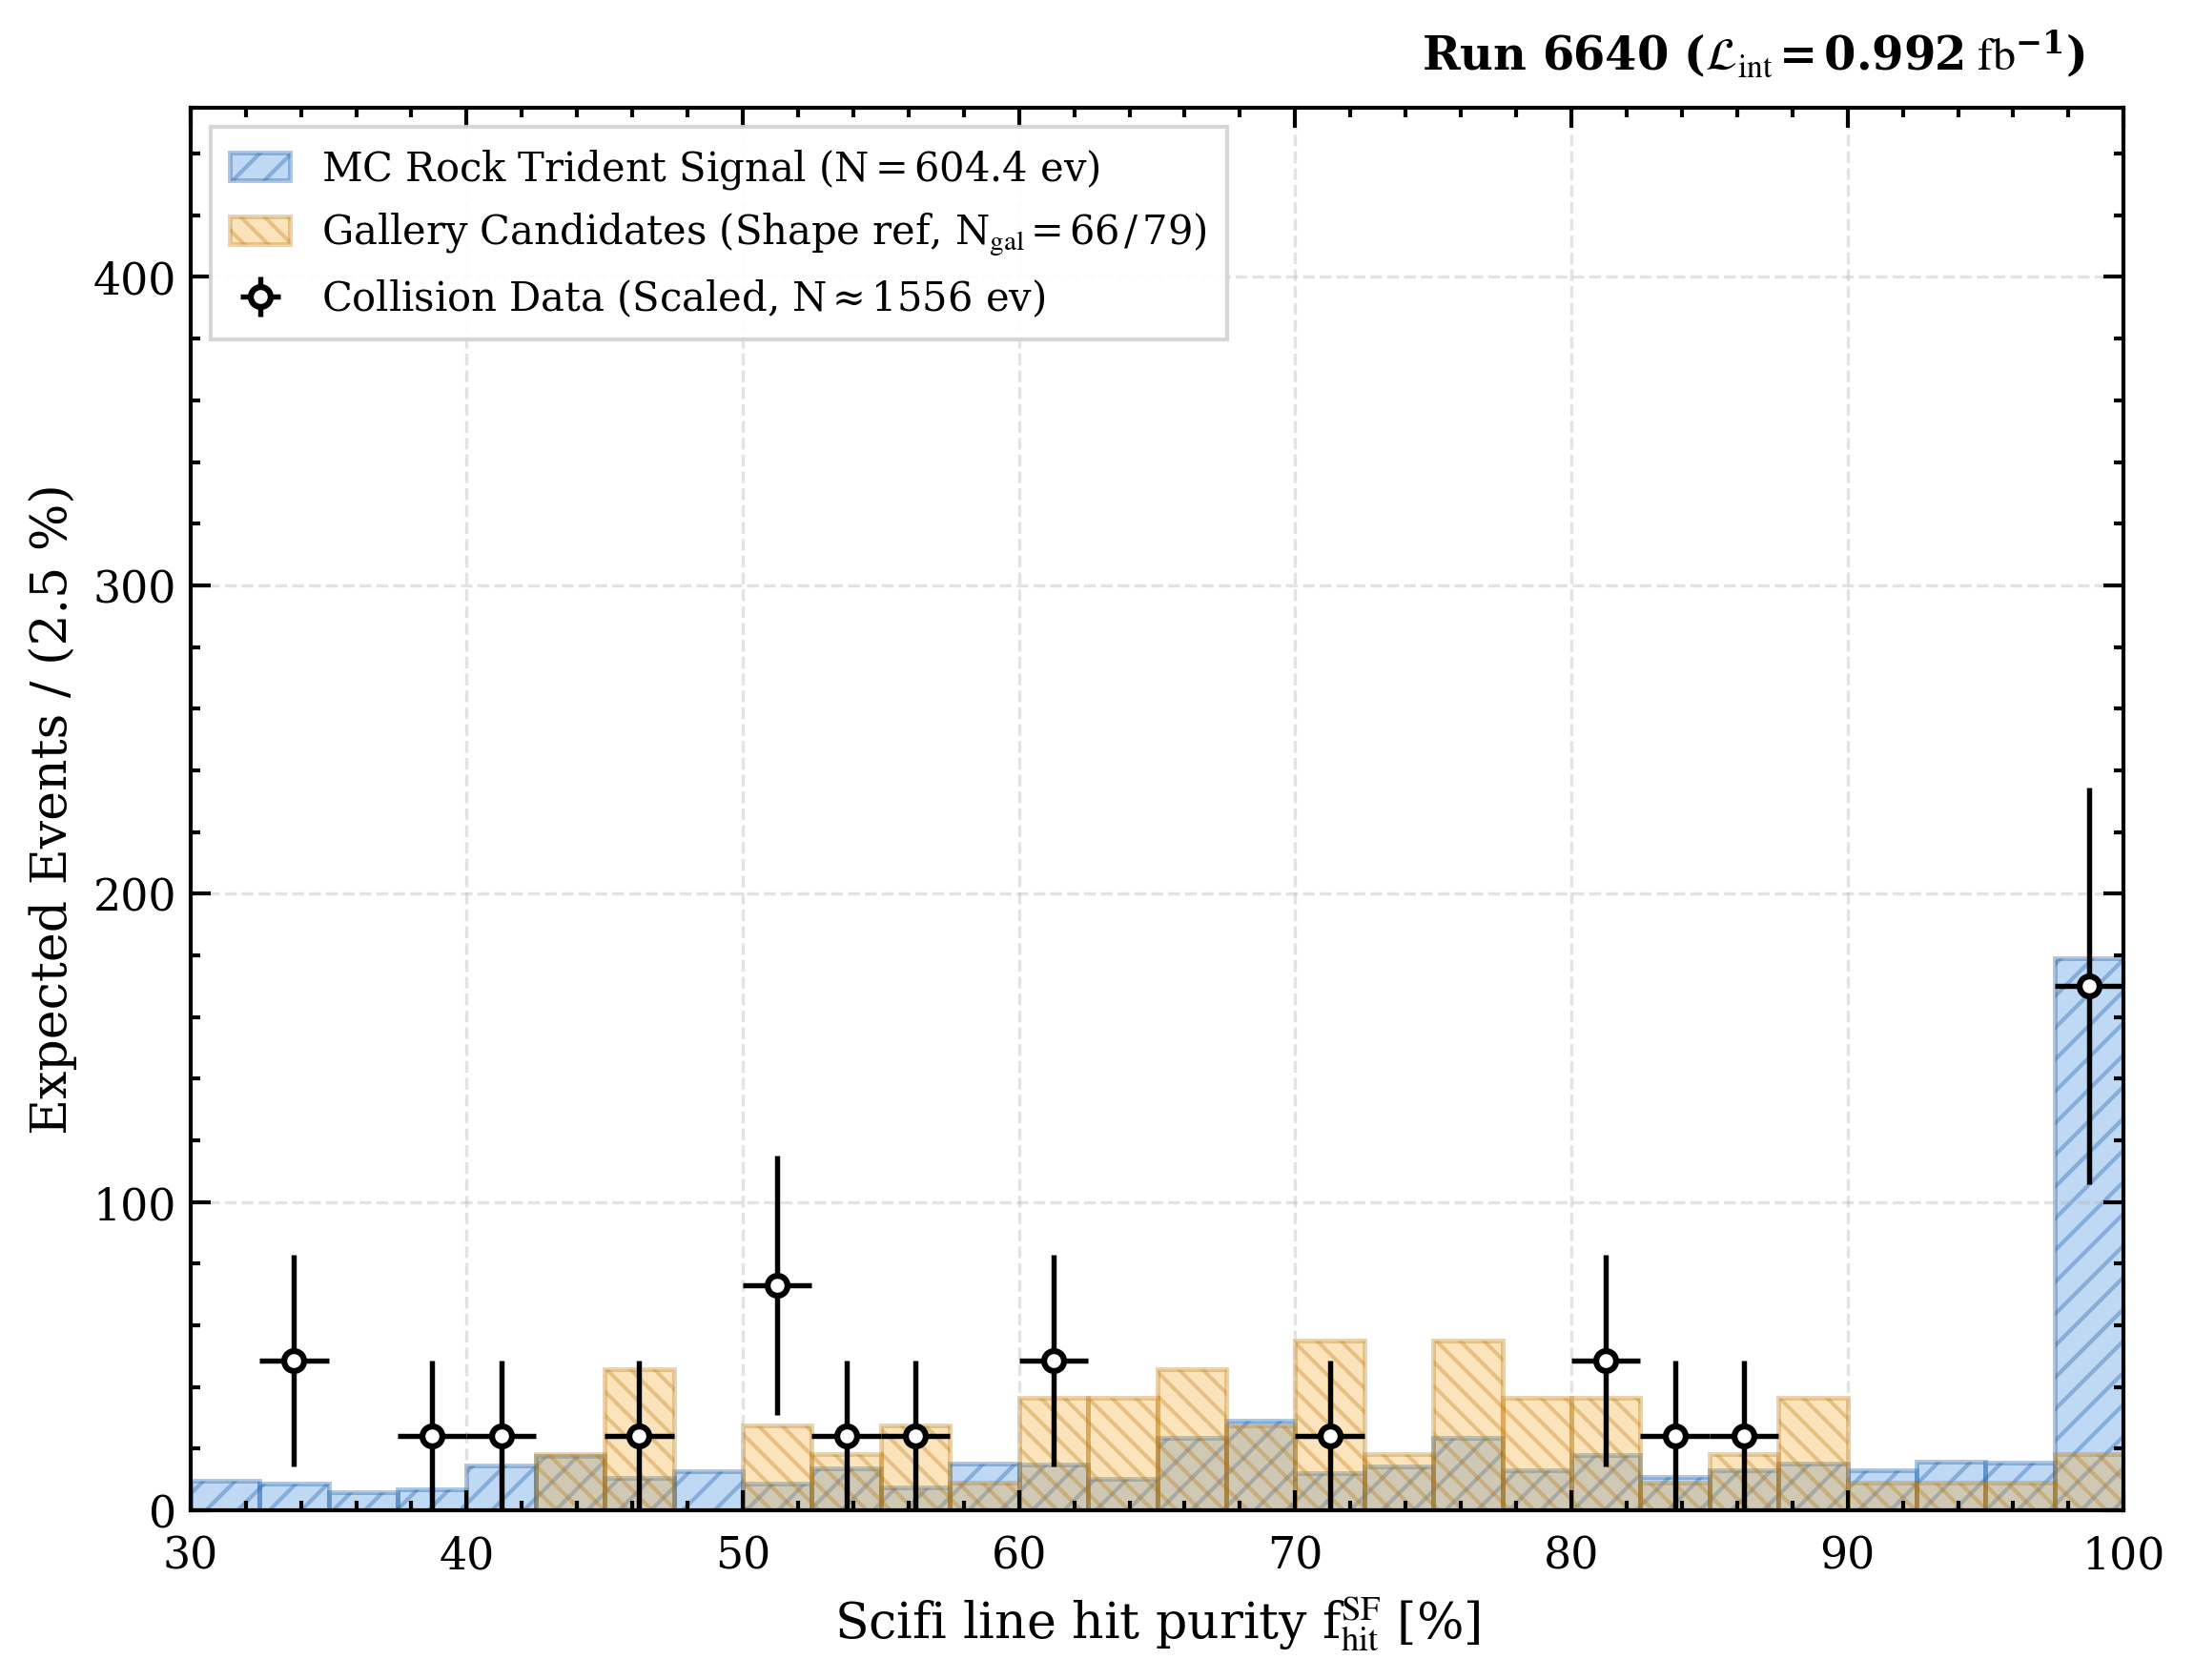

In [55]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ==============================================================================
# 1. LUMINOSITY & SCALE FACTORS
# ==============================================================================
LUMI_SUB_DATA = 0.040777061918046364
LUMI_FULL_6640 = 0.9915864253712848
LUMI_MC_DATASET = 0.0250

SCALE_DATA_TO_FULL = LUMI_FULL_6640 / LUMI_SUB_DATA  # ~24.32
SCALE_MC_TO_FULL = LUMI_FULL_6640 / LUMI_MC_DATASET  # ~39.66

# Expected physical yields in full Run 6640
n_data_full_expected = len(sel_data) * SCALE_DATA_TO_FULL
mc_weights_full = sel_mc["mc_weight"].to_numpy() * SCALE_MC_TO_FULL
n_mc_full_expected = mc_weights_full.sum()

# ==============================================================================
# 2. FIGURE & STYLE SETUP
# ==============================================================================
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12.5,
        "axes.titlesize": 12.5,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    }
)

fig, ax = plt.subplots(figsize=(7.8, 6.0), dpi=300)

# Binning: 2.5% fixed bin width (28 bins from 30% to 100%)
bin_width = 2.5
bins = np.arange(30.0, 100.0 + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# ==============================================================================
# 3. YIELD-SCALED HISTOGRAMS & DATA POINTS (FULL RUN 6640)
# ==============================================================================

# 1. MC Rock Trident Signal (Scaled Yield)
ax.hist(
    purity_mc_sel,
    bins=bins,
    weights=mc_weights_full,
    facecolor="#4A90E2",
    alpha=0.35,
    hatch="///",
    edgecolor="#1C5FA8",
    linewidth=1.2,
    label=rf"MC Rock Trident Signal ($N = {n_mc_full_expected:.1f}$ ev)",
)

# 2. Gallery Candidates (Shape-normalized to MC yield)
gal_weights = np.full(
    len(purity_gal_sel), n_mc_full_expected / len(purity_gal_sel)
)
ax.hist(
    purity_gal_sel,
    bins=bins,
    weights=gal_weights,
    facecolor="#F5A623",
    alpha=0.30,
    hatch=r"\\\\",
    edgecolor="#B87300",
    linewidth=1.2,
    label=rf"Gallery Candidates (Shape ref, $N_{{\mathrm{{gal}}}} = {len(sel_gal)} \,/\, 79$)",
)

# 3. Collision Data (Scaled Poisson Points)
purity_data_in_range = purity_data_sel[
    (purity_data_sel >= bins[0]) & (purity_data_sel <= bins[-1])
]
counts_data_raw, _ = np.histogram(purity_data_in_range, bins=bins)

counts_data_scaled = counts_data_raw * SCALE_DATA_TO_FULL
err_data_scaled = np.sqrt(counts_data_raw) * SCALE_DATA_TO_FULL

mask_nonzero = counts_data_raw > 0
ax.errorbar(
    bin_centers[mask_nonzero],
    counts_data_scaled[mask_nonzero],
    yerr=err_data_scaled[mask_nonzero],
    xerr=bin_width / 2.0,
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.3,
    capsize=0,
    markersize=5,
    zorder=10,
    label=rf"Collision Data (Scaled, $N \approx {n_data_full_expected:.0f}$ ev)",
)

# ==============================================================================
# 4. METADATA, AXES & LEGEND
# ==============================================================================
ax.text(
    0.98,
    1.02,
    rf"Run 6640 ($\mathcal{{L}}_{{\mathrm{{int}}}} = {LUMI_FULL_6640:.3f}\ \mathrm{{fb}}^{{-1}}$)",
    transform=ax.transAxes,
    fontsize=11.5,
    ha="right",
    va="bottom",
    fontweight="semibold",
)

ax.set_xlabel(r"Scifi line hit purity $f_{\mathrm{hit}}^{\mathrm{SF}}$ [%]")
ax.set_ylabel(rf"Expected Events / ({bin_width:.1f} %)")

ax.set_xlim(30, 100)
y_max = max(counts_data_scaled.max(), 350)
ax.set_ylim(bottom=0, top=y_max * 1.30)

# Ticks configuration
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(
    which="both", direction="in", top=True, right=True, length=5, width=1.0
)
ax.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

ax.grid(True, linestyle="--", alpha=0.35)

# Standalone Legend Box
ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    edgecolor="lightgray",
    facecolor="white",
)

plt.tight_layout()
plt.show()

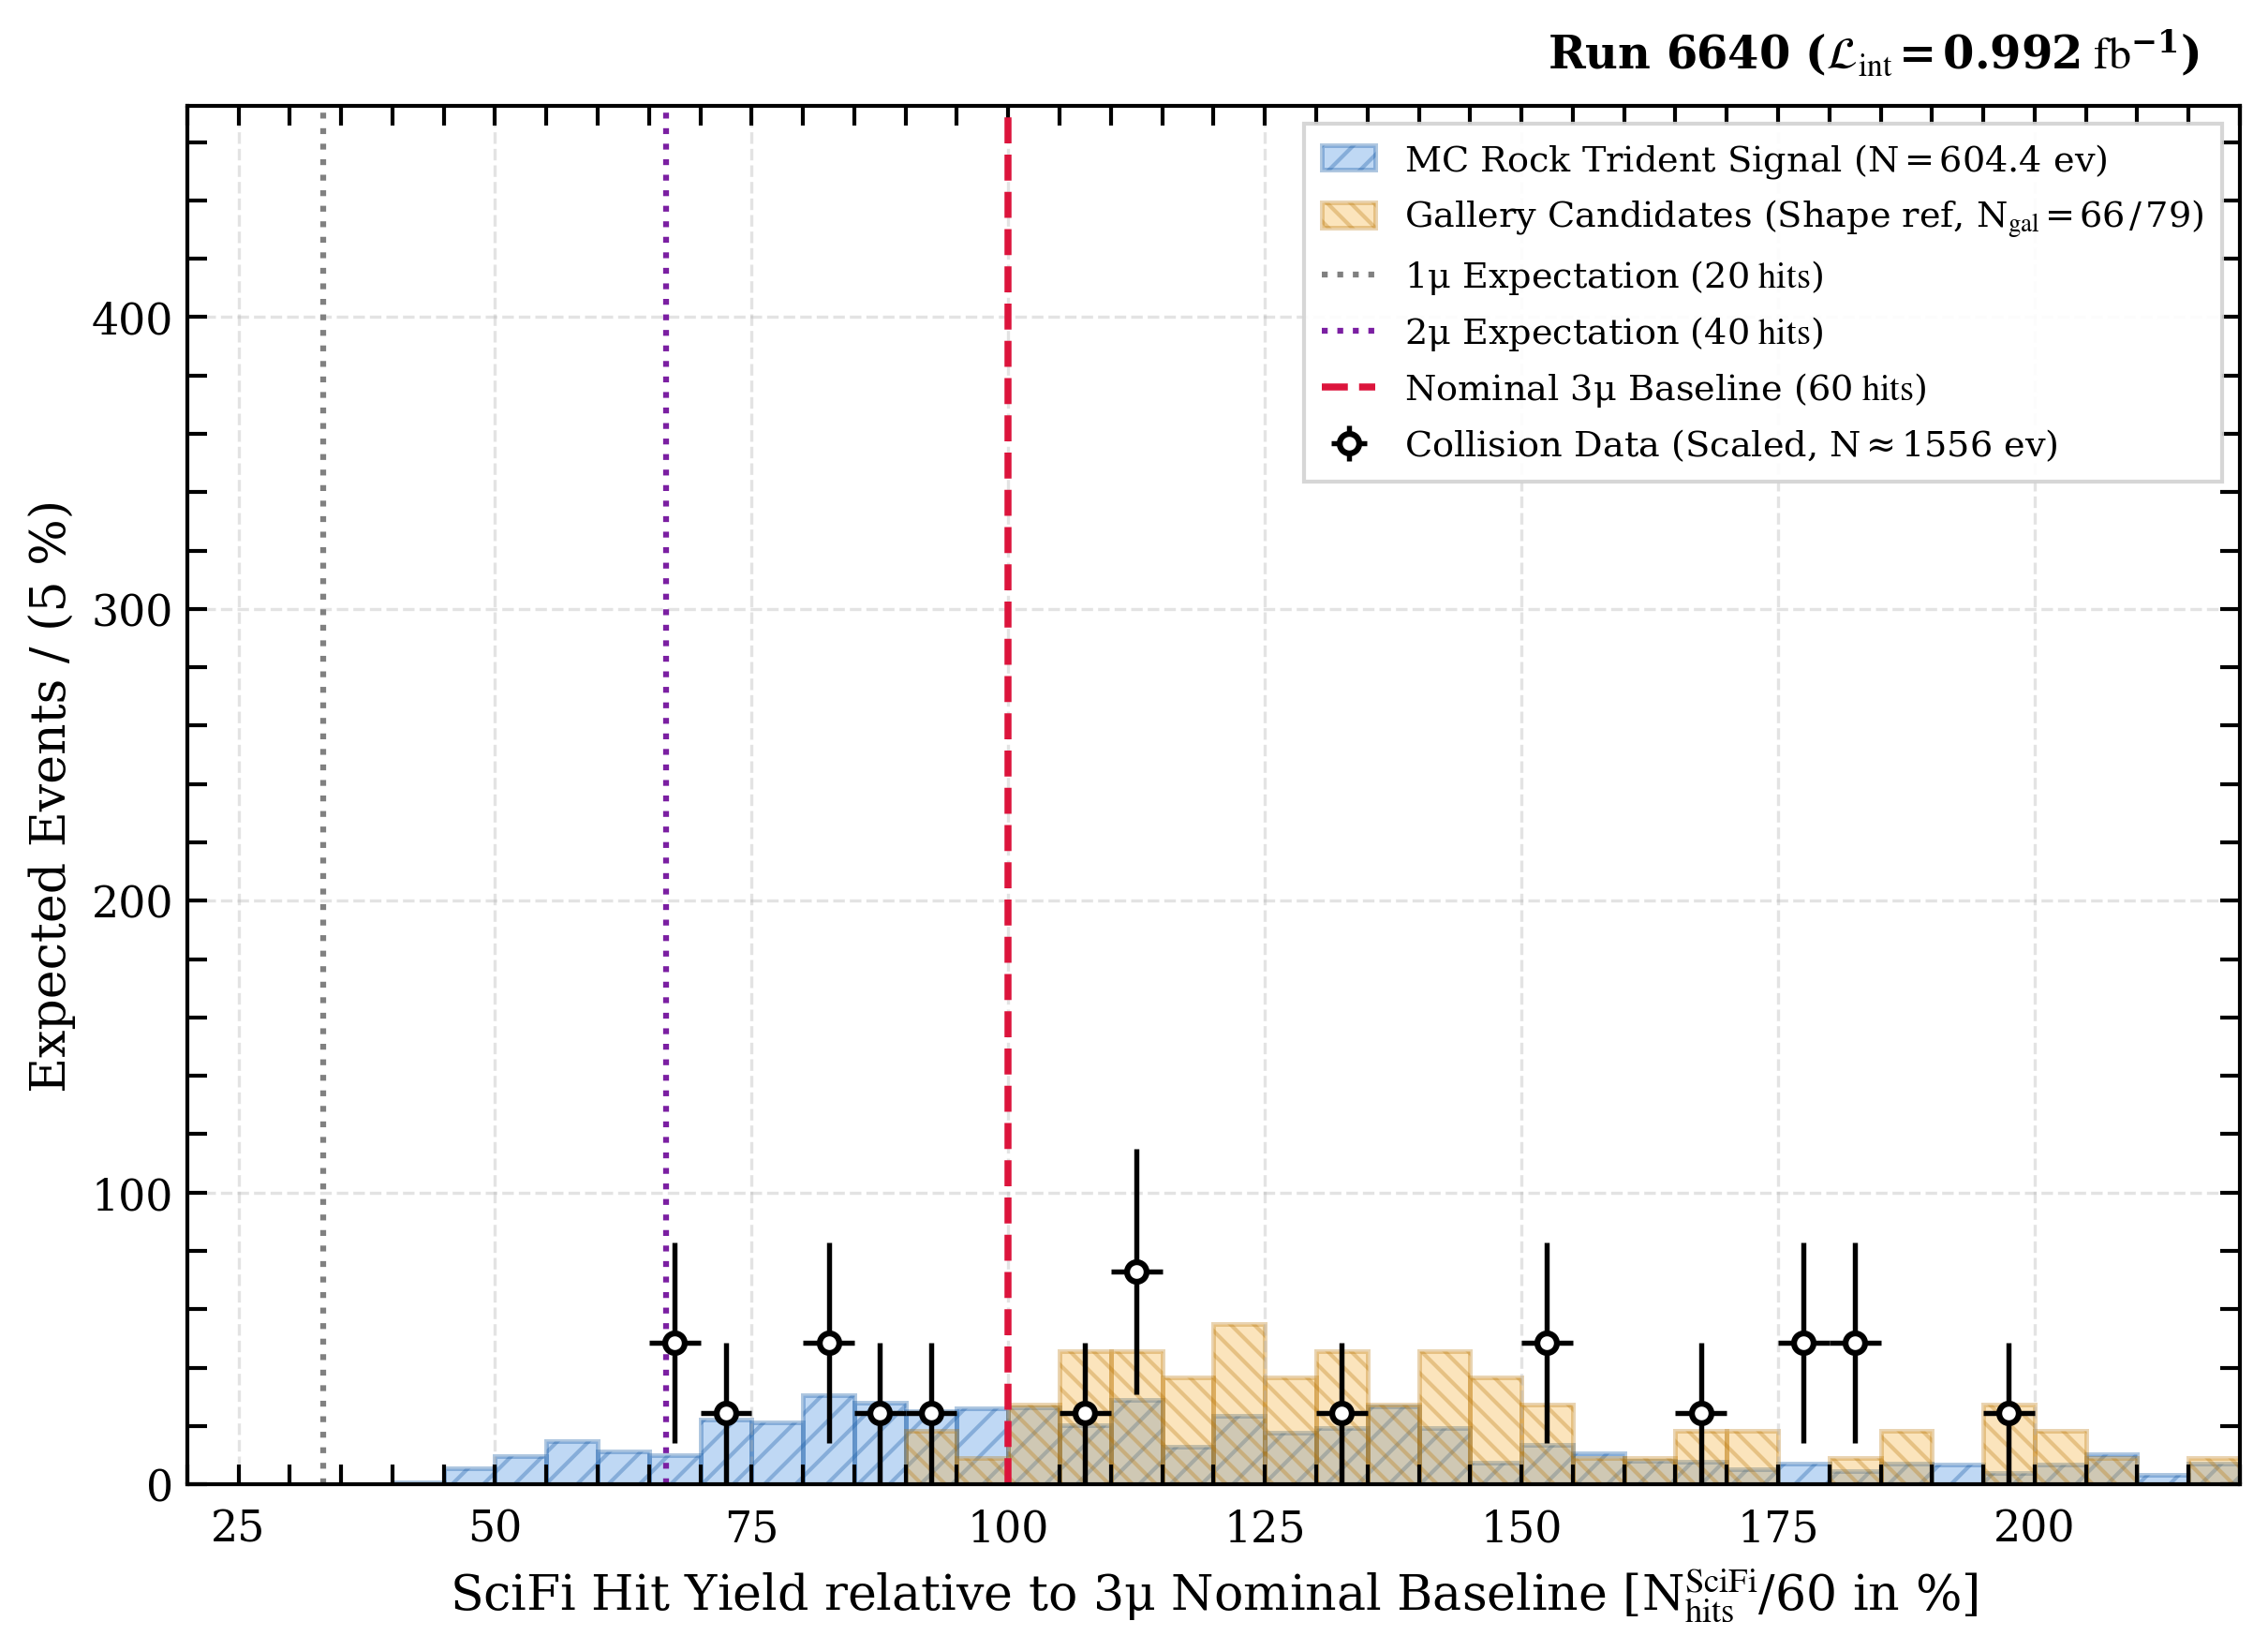

In [71]:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    
    # Compute un-capped normalized hit fraction relative to 60 hits (in %)
    ratio_data = (sel_data["scifi_nhits"].to_numpy() / 60.0) * 100.0
    ratio_mc = (sel_mc["scifi_nhits"].to_numpy() / 60.0) * 100.0
    ratio_gal = (sel_gal["scifi_nhits"].to_numpy() / 60.0) * 100.0
    
    fig, ax = plt.subplots(figsize=(8.2, 6.0), dpi=300)
    
    # Binning from 20% to 220% with 5% wide bins
    bin_width = 5.0
    bins = np.arange(20.0, 220.0 + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # 1. MC Rock Trident Signal
    ax.hist(
        ratio_mc,
        bins=bins,
        weights=mc_weights_full,
        facecolor="#4A90E2",
        alpha=0.35,
        hatch="///",
        edgecolor="#1C5FA8",
        linewidth=1.2,
        label=rf"MC Rock Trident Signal ($N = {n_mc_full_expected:.1f}$ ev)",
    )
    
    # 2. Gallery Candidates (Shape-normalized)
    gal_weights = np.full(len(ratio_gal), n_mc_full_expected / len(ratio_gal))
    ax.hist(
        ratio_gal,
        bins=bins,
        weights=gal_weights,
        facecolor="#F5A623",
        alpha=0.30,
        hatch=r"\\\\",
        edgecolor="#B87300",
        linewidth=1.2,
        label=(
            r"Gallery Candidates (Shape ref,"
            rf" $N_{{\mathrm{{gal}}}} = {len(sel_gal)} \,/\, 79$)"
        ),
    )
    
    # 3. Collision Data (Poisson scaled)
    counts_data_raw, _ = np.histogram(ratio_data, bins=bins)
    counts_data_scaled = counts_data_raw * SCALE_DATA_TO_FULL
    err_data_scaled = np.sqrt(counts_data_raw) * SCALE_DATA_TO_FULL
    
    mask_nonzero = counts_data_raw > 0
    ax.errorbar(
        bin_centers[mask_nonzero],
        counts_data_scaled[mask_nonzero],
        yerr=err_data_scaled[mask_nonzero],
        xerr=bin_width / 2.0,
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=1.3,
        capsize=0,
        markersize=5,
        zorder=10,
        label=rf"Collision Data (Scaled, $N \approx {n_data_full_expected:.0f}$ ev)",
    )
    
    # Reference Lines for 1-MIP, 2-MIP, and 3-MIP expectations
    ax.axvline(
        33.3,
        color="gray",
        linestyle=":",
        lw=1.5,
        label=r"$1\mu$ Expectation ($20\ \mathrm{hits}$)",
    )
    ax.axvline(
        66.7,
        color="#7B1FA2",
        linestyle=":",
        lw=1.5,
        label=r"$2\mu$ Expectation ($40\ \mathrm{hits}$)",
    )
    ax.axvline(
        100.0,
        color="crimson",
        linestyle="--",
        lw=1.8,
        label=r"Nominal $3\mu$ Baseline ($60\ \mathrm{hits}$)",
    )

    ax.text(
        0.98,
        1.02,
        rf"Run 6640 ($\mathcal{{L}}_{{\mathrm{{int}}}} = {LUMI_FULL_6640:.3f}\ \mathrm{{fb}}^{{-1}}$)",
        transform=ax.transAxes,
        fontsize=11.5,
        ha="right",
        va="bottom",
        fontweight="semibold",
    )

    ax.set_xlabel(
        r"SciFi Hit Yield relative to $3\mu$ Nominal Baseline"
        r" [$N_{\mathrm{hits}}^{\mathrm{SciFi}} / 60$ in %]"
    )
    ax.set_ylabel(rf"Expected Events / ({bin_width:.0f} %)")

    ax.set_xlim(20, 220)
    ax.set_ylim(bottom=0, top=max(counts_data_scaled.max(), 350) * 1.35)

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(
        which="both", direction="in", top=True, right=True, length=5, width=1.0
    )
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(
        loc="upper right",
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        fontsize=9.2,
    )

    plt.tight_layout()
    plt.show()




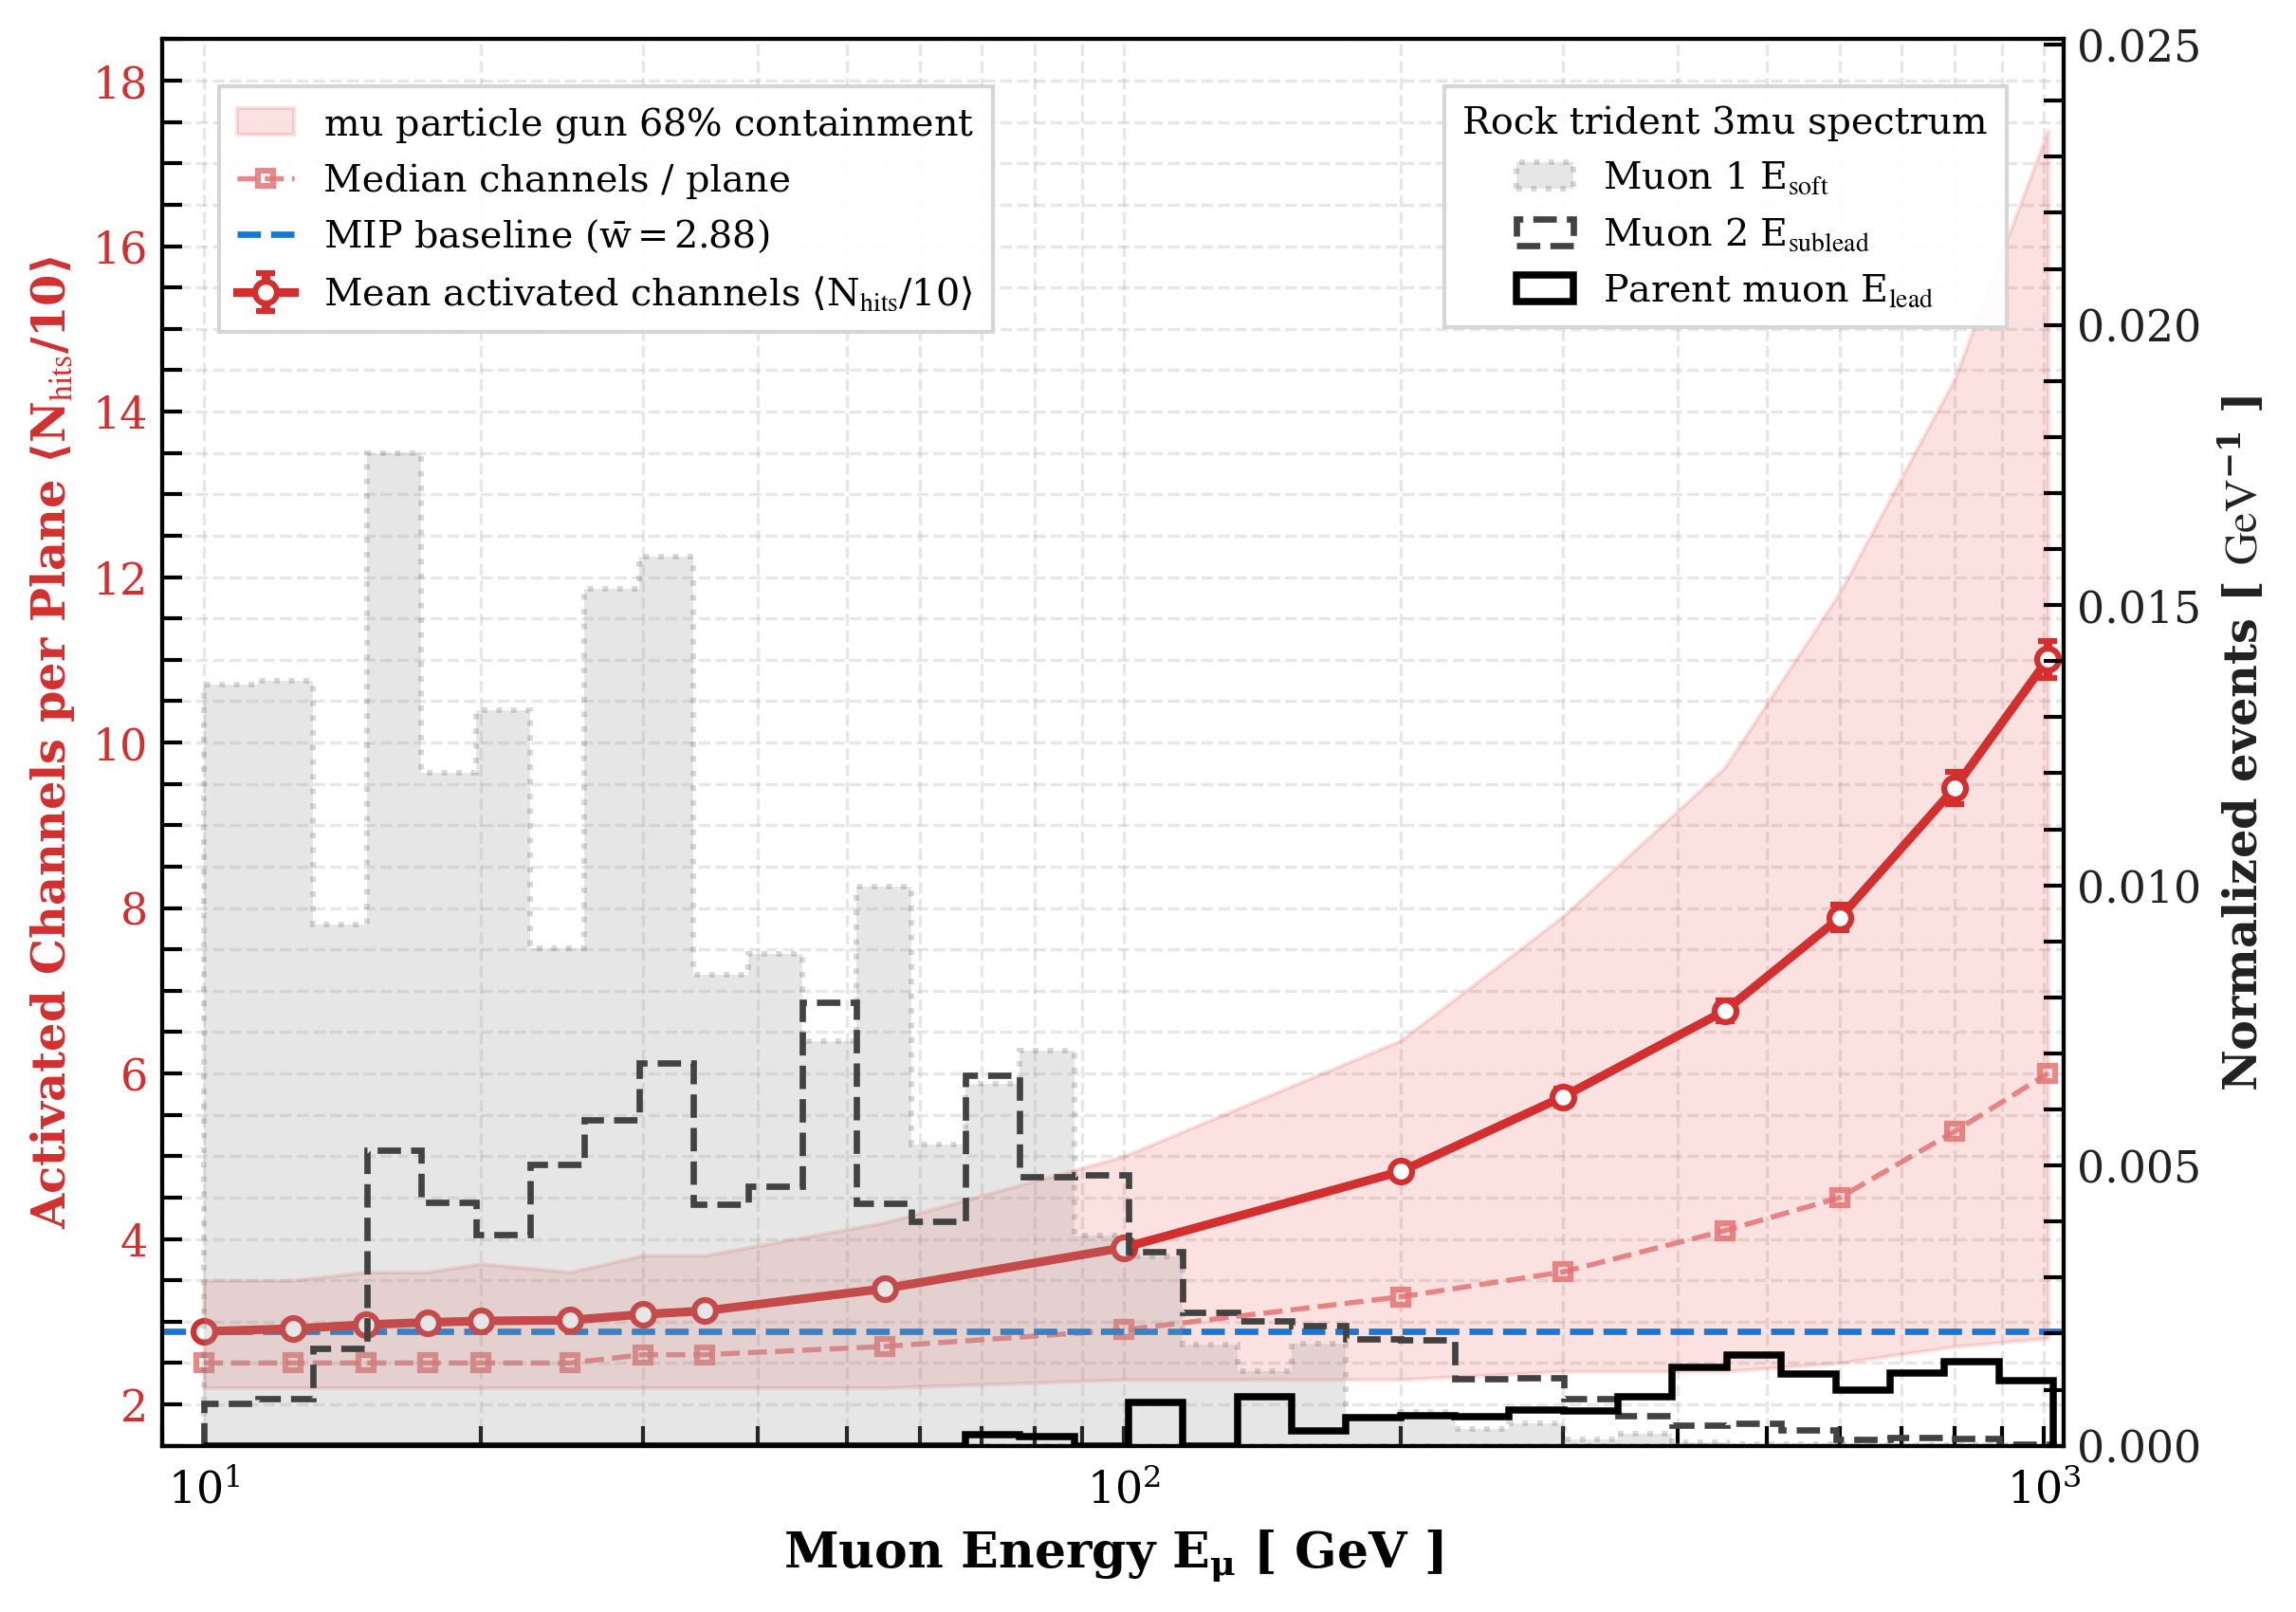

In [69]:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    
    # ==============================================================================
    # PUBLICATION-QUALITY STANDALONE RESPONSE & ENERGY SPECTRUM PLOT
    # ==============================================================================
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12.5,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9.5,
    })
    
    fig, ax1 = plt.subplots(figsize=(8.2, 5.8), dpi=300)
    bins_energy = np.logspace(1.0, 3.01, 35)  # 10 GeV to ~1010 GeV
    
    # ------------------------------------------------------------------------------
    # 1. RIGHT AXIS (Background): Post-Selection Trident Muon Energy Hierarchy
    # ------------------------------------------------------------------------------
    ax1_twin = ax1.twinx()
    
    # Softest Muon (Lightest shading + dotted line)
    ax1_twin.hist(
        e_soft,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="stepfilled",
        facecolor="#9E9E9E",
        alpha=0.25,
        edgecolor="#616161",
        linestyle=":",
        linewidth=1.4,
        zorder=1,
        label=r"Muon 1 $E_{\mathrm{soft}}$",
    )
    
    # Sub-Leading Muon (Medium step outline)
    ax1_twin.hist(
        e_sublead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="#424242",
        linestyle="--",
        linewidth=1.6,
        zorder=2,
        label=r"Muon 2 $E_{\mathrm{sublead}}$",
    )
    
    # Leading Muon (Bold black step outline)
    ax1_twin.hist(
        e_lead,
        bins=bins_energy,
        weights=w_mc,
        density=True,
        histtype="step",
        color="black",
        linestyle="-",
        linewidth=1.8,
        zorder=3,
        label=r"Parent muon $E_{\mathrm{lead}}$",
    )
    
    ax1_twin.set_ylabel(
        r"Normalized events [ $\mathrm{GeV}^{-1}$ ]",
        fontweight="bold",
        fontsize=11.5,
        color="#212121",
    )
    ax1_twin.tick_params(axis="y", labelcolor="#212121")
    ax1_twin.set_ylim(0, ax1_twin.get_ylim()[1] * 1.35)
    
    # ------------------------------------------------------------------------------
    # 2. LEFT AXIS (Foreground): Particle Gun Detector Cluster Size (Mean & Median)
    # ------------------------------------------------------------------------------
    # 68% containment interval band
    ax1.fill_between(
        df_pgun["energy_gev"],
        df_pgun["q16_per_plane"],
        df_pgun["q84_per_plane"],
        color="#E53935",
        alpha=0.15,
        zorder=4,
        label=r"mu particle gun $68\%$ containment",
    )
    
    # Subtle Median response (dashed, muted in background)
    ax1.plot(
        df_pgun["energy_gev"],
        df_pgun["median_per_plane"],
        marker="s",
        markersize=3.8,
        markerfacecolor="none",
        markeredgecolor="#E57373",
        linestyle="--",
        color="#E57373",
        lw=1.3,
        alpha=0.85,
        zorder=5,
        label=r"Median channels / plane",
    )
    
    # Prominent Mean cluster size per plane
    ax1.errorbar(
        df_pgun["energy_gev"],
        df_pgun["mean_per_plane"],
        yerr=df_pgun["sem_per_plane"],
        fmt="o-",
        color="#D32F2F",
        ecolor="#D32F2F",
        lw=2.2,
        markersize=5.5,
        capsize=2.5,
        zorder=7,
        label=r"Mean activated channels $\langle N_{\mathrm{hits}} / 10 \rangle$",
    )
    
    # MIP Plateau reference line
    ax1.axhline(
        2.88,
        color="#1976D2",
        linestyle="--",
        lw=1.6,
        zorder=6,
        label=r"MIP baseline ($\bar{w} = 2.88$)",
    )
    
    ax1.set_xscale("log")
    ax1.set_xlim(9, 1050)
    ax1.set_ylim(1.5, 18.5)
    
    ax1.set_xlabel(r"Muon Energy $E_{\mu}$ [ GeV ]", fontweight="bold")
    ax1.set_ylabel(
        r"Activated Channels per Plane $\langle N_{\mathrm{hits}} / 10 \rangle$",
        fontweight="bold",
        fontsize=11.5,
        color="#D32F2F",
    )
    ax1.tick_params(axis="y", labelcolor="#D32F2F")

    # Minor tick formatters
    ax1.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto"))
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax1.tick_params(
        which="both", direction="in", top=False, right=False, length=5, width=1.0
    )
    ax1_twin.tick_params(
        which="both", direction="in", top=False, right=True, length=5, width=1.0
    )
    ax1.grid(True, which="both", linestyle="--", alpha=0.3)

    # ------------------------------------------------------------------------------
    # 3. SPLIT LEGENDS FOR READABILITY
    # ------------------------------------------------------------------------------
    # Left Legend: Detector Calibration / Particle Gun
    ax1.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title_fontsize=9.5,
    )

    # Right Legend: Trident Kinematics
    ax1_twin.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        framealpha=0.92,
        edgecolor="lightgray",
        title=r"Rock trident 3mu spectrum",
        title_fontsize=9.5,
    )

    plt.tight_layout()
    plt.show()


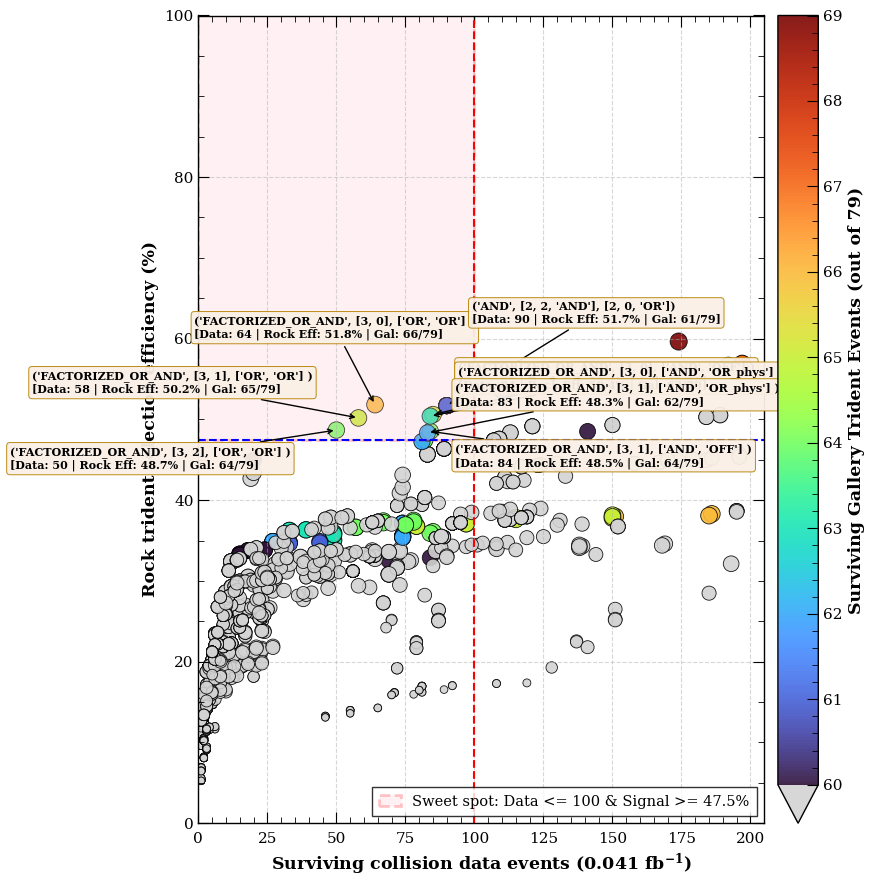

In [62]:
df = pd.read_parquet('topological_criteria_scan_unified.parquet')
df_zoom = df[(df['data_events'] > 0) & (df['data_events'] <= 200)].copy()

# 2. Filter for points strictly inside the sweet spot
df_ul = df_zoom[
    (df_zoom['data_events'] <= 100) & (df_zoom['rock_eff_pct'] >= 47.5)
].sort_values(by=['rock_eff_pct', 'gallery_events'], ascending=[False, False])

unique_ul_dict = {}
for _, r in df_ul.iterrows():
    key = (r['data_events'], round(r['rock_eff_pct'], 1))
    if key not in unique_ul_dict:
        unique_ul_dict[key] = r

custom_cmap = mpl.colormaps['turbo'].copy()
custom_cmap.set_under('lightgray')

# 2. Create Figure & Axes explicitly
fig, ax = plt.subplots(figsize=(9, 9))

max_gallery = df_zoom['gallery_events'].max()

sc = ax.scatter(
    df_zoom['data_events'],
    df_zoom['rock_eff_pct'],
    c=df_zoom['gallery_events'],
    s=df_zoom['gallery_events'] * 2.2,
    cmap=custom_cmap,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.6,
    vmin=60,
    vmax=max_gallery,
)

# Attach colorbar directly to fig
cbar = fig.colorbar(sc, ax=ax, pad=0.02, extend='min')
cbar.set_label(
    f'Surviving Gallery Trident Events (out of 79)',
    fontweight='bold',
)

ax.set_xlabel(
    'Surviving collision data events (0.041 fb$^{-1}$)', fontweight='bold'
)
ax.set_ylabel('Rock trident selection efficiency (%)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

# 4. Highlight Sweet Spot Region (0 <= Data <= 100 & 47.5 <= Signal <= 100)
ul_box = patches.Rectangle(
    (0, 47.5),
    100,
    52.5,
    linewidth=2,
    edgecolor='red',
    facecolor='pink',
    alpha=0.22,
    linestyle='--',
    label='Sweet spot: Data <= 100 & Signal >= 47.5%',
)
ax.add_patch(ul_box)
ax.set_xlim(0, 205)
ax.set_ylim(0, 100)
ax.axvline(100, color='red', linestyle='--', linewidth=1.5)
ax.axhline(47.5, color='blue', linestyle='--', linewidth=1.5)
ax.legend(loc='lower right', fontsize=10.5)

# 5. Non-overlapping annotation offsets for canonical Config labels
custom_offsets = {
    (50, 48.7): (-235, -28),
    (58, 50.2): (-235, 18),
    (64, 51.8): (-130, 48),
    (84, 48.5): (18, -25),
    (85, 50.6): (18, 22),
    (90, 51.7): (18, 60),
}

for (x_val, y_val), r in unique_ul_dict.items():
    ox, oy = custom_offsets.get(
        (r['data_events'], round(r['rock_eff_pct'], 1)), (20, 20)
    )
    ann_text = (
        r['label']
        + '\n'
        + f"[Data: {r['data_events']} | Rock Eff: {r['rock_eff_pct']:.1f}% | Gal:"
        f" {r['gallery_events']}/79]"
    )
    ax.annotate(
        ann_text,
        xy=(r['data_events'], r['rock_eff_pct']),
        xytext=(ox, oy),
        textcoords='offset points',
        fontsize=8.0,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='linen',
            alpha=0.95,
            edgecolor='darkgoldenrod',
            linewidth=0.7,
        ),
        arrowprops=dict(arrowstyle='->', lw=1.0, color='black'),
    )

plt.tight_layout()
plt.show()

In [34]:
def apply_factorized_30_or_or(df: pd.DataFrame) -> pd.DataFrame:
    def check_non_crossing(prefix: str, proj: str, z_min: float, z_max: float):
        n_lines = df[f'n_lines_{prefix}_{proj}'].to_numpy()
        m1 = df[f'{proj}_{prefix}_m1'].to_numpy()
        c1 = df[f'{proj}_{prefix}_c1'].to_numpy()
        m2 = df[f'{proj}_{prefix}_m2'].to_numpy()
        c2 = df[f'{proj}_{prefix}_c2'].to_numpy()
        m3 = df[f'{proj}_{prefix}_m3'].to_numpy()
        c3 = df[f'{proj}_{prefix}_c3'].to_numpy()

        x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
        x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
        x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3

        no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
        no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
        no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0


        pass_3 = (n_lines >= 3) & no_cross_12 & no_cross_13 & no_cross_23
        pass_2 = (n_lines == 2) & no_cross_12
        return pass_3 | pass_2

    # -------------------------------------------------------------
    # 1. Multiplicity: >= 3 lines in at least one view of SF OR DS
    # -------------------------------------------------------------
    mult_sf_xz = df['n_lines_sf_xz'] >= 3
    mult_sf_yz = df['n_lines_sf_yz'] >= 3
    mult_ds_xz = df['n_lines_ds_xz'] >= 3
    mult_ds_yz = df['n_lines_ds_yz'] >= 3
    mult_mask = (mult_sf_xz | mult_sf_yz | mult_ds_xz | mult_ds_yz).to_numpy()

    # -------------------------------------------------------------
    # 2. Collinearity in SciFi: non-crossing in XZ OR YZ (Z in [260, 355] cm)
    # -------------------------------------------------------------
    nc_sf_xz = check_non_crossing('sf', 'xz', 260.0, 355.0)
    nc_sf_yz = check_non_crossing('sf', 'yz', 260.0, 355.0)
    coll_sf = nc_sf_xz | nc_sf_yz

    # -------------------------------------------------------------
    # 3. Collinearity in DS: non-crossing in XZ OR YZ (Z in [460, 590] cm)
    # -------------------------------------------------------------
    nc_ds_xz = check_non_crossing('ds', 'xz', 460.0, 590.0)
    nc_ds_yz = check_non_crossing('ds', 'yz', 460.0, 590.0)
    coll_ds = nc_ds_xz | nc_ds_yz

    # -------------------------------------------------------------
    # 4. Final Combined Selection Mask
    # -------------------------------------------------------------
    final_mask = mult_mask & coll_sf & coll_ds
    return df[final_mask].copy()

In [ ]:
def get_32_or(df):
    return (((df['n_lines_sf_xz'] >= 3) & (df['n_lines_sf_yz'] >= 2)) | \
            ((df['n_lines_sf_yz'] >= 3) & (df['n_lines_sf_xz'] >= 2))) | \
            (((df['n_lines_ds_xz'] >= 3) & (df['n_lines_ds_yz'] >= 2)) | \
            ((df['n_lines_ds_yz'] >= 3) & (df['n_lines_ds_xz'] >= 2)))

# 2. Apply the Highest Significance Cutset (S/√(S+B) = 3.886)
max_sig_mc = get_32_or(mc_df) & (mc_df['ds_sum_qdc_weight_density'] >= 2000)
max_sig_dt = get_32_or(data)  & (data['ds_sum_qdc_weight_density'] >= 2000)

# 3. Clean Anti-Showering Version (Rejects shower events like #16279249)
clean_sig_mc = max_sig_mc & (mc_df['scifi_nhits'] <= 150)
clean_sig_dt = max_sig_dt & (data['scifi_nhits'] <= 150)

# Evaluate
sig_rock = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 1)]
bkg_mc   = mc_df[mc_df['is_signal'] == 0]
w_rock_tot = sig_rock['mc_weight'].sum()
w_bkg_tot  = bkg_mc['mc_weight'].sum()

for label, m_mc, m_dt in [("1. Absolute Highest Significance Cutset", max_sig_mc, max_sig_dt),
                            ("2. Clean Anti-Showering Cutset", clean_sig_mc, clean_sig_dt)]:
    tp_w = sig_rock.loc[m_mc.loc[sig_rock.index], 'mc_weight'].sum()
    fp_w = bkg_mc.loc[m_mc.loc[bkg_mc.index], 'mc_weight'].sum()
    n_dt = int(m_dt.sum())
    
    print("=" * 68)
    print(f"  {label}")
    print("=" * 68)
    print(f"Statistical Significance S/√(S+B) : {tp_w / np.sqrt(tp_w + fp_w):.3f}")
    print(f"Rock Signal Efficiency (TPR)     : {tp_w / w_rock_tot * 100.0:.2f} %")
    print(f"Signal Purity (Precision)        : {tp_w / (tp_w + fp_w) * 100.0:.2f} %")
    print(f"Real Data Pass Rate              : {n_dt:,} / {len(data):,} ({n_dt /
len(data) * 100.0:.4f} %)")
    print(f"Data Reduction Factor            : {len(data) / n_dt:.1f}x")
    print("=" * 68 + "\n")


In [ ]:
df['pass_topo_3_1'] = (
    (
        ((df['n_lines_sf_xz'] >= 3) & (df['n_lines_sf_yz'] >= 1)) |
        ((df['n_lines_sf_yz'] >= 3) & (df['n_lines_sf_xz'] >= 1))
    ) | (
        ((df['n_lines_ds_xz'] >= 3) & (df['n_lines_ds_yz'] >= 3))
    )
)

def calc_efficiency(group, pass_col="pass_topo_3_1", weight_col="mc_weight"):
    # Ensure boolean/integer mask without NaNs
    pass_mask = group[pass_col].fillna(0).astype(bool)
    w = group[weight_col].fillna(0).to_numpy()

    raw_tot = len(group)
    raw_pass = int(pass_mask.sum())
    raw_eff = (raw_pass / raw_tot * 100.0) if raw_tot > 0 else 0.0

    w_tot = float(w.sum())
    w_pass = float(w[pass_mask].sum())
    w_eff = (w_pass / w_tot * 100.0) if w_tot > 0 else 0.0

    # Optional: Weighted binomial error calculation
    if w_tot > 0 and raw_tot > 0:
        eff_frac = w_pass / w_tot
        var = np.sum((pass_mask.to_numpy() - eff_frac) ** 2 * (w**2))
        w_err = np.sqrt(var) / w_tot * 100.0
    else:
        w_err = 0.0

    return pd.Series(
        {
            "Raw_Total": raw_tot,
            "Raw_Passed": raw_pass,
            "Raw_Eff_%": raw_eff,
            "Wtd_Total": w_tot,
            "Wtd_Passed": w_pass,
            "Wtd_Eff_%": w_eff,
            "Wtd_Eff_Err_%": w_err,
        }
    )

In [ ]:
sig_df = df[df['is_signal']==1]

In [ ]:
print("=== TOPOLOGY (3 in one, >=1 in other) EFFICIENCY ===")
sig_df.groupby('region_type').apply(calc_efficiency, pass_col='pass_topo_3_1', include_groups=False)

In [ ]:
z_fid = 320.0
xmin, xmax = -42.0, -11.0
ymin, ymax = 18.0, 49.0

x_at_z1 = df['xz_m1'] * z_fid + df['xz_c1']
y_at_z1 = df['yz_m1'] * z_fid + df['yz_c1']

fid_mask_trk1 = (
    (x_at_z1 >= xmin) & (x_at_z1 <= xmax) &
    (y_at_z1 >= ymin) & (y_at_z1 <= ymax)
)

df['pass_topo_and_fid'] = df['pass_topo_3_1'] & fid_mask_trk1

sig_df = df[df['is_signal'] == 1]

In [ ]:
print("\n=== COMBINED (TOPOLOGY + FIDUCIAL) EFFICIENCY ===")
sig_df.groupby('region_name').apply(calc_efficiency, pass_col='pass_topo_and_fid', include_groups=False)

In [ ]:
print("\n=== EFFICIENCY BY PROCESS TYPE ===")
sig_df.groupby('proc_type').apply(calc_efficiency, pass_col='pass_topo_3_1', include_groups=False)

In [ ]:
sig_rock = df[df['region_type'] == 1]
sig_tgt = df[df['region_type'] == 2]
bkg = df[df['is_signal'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (title, sub) in enumerate([
    ("target_3mu", sig_tgt), 
    ("rock_3mu", sig_rock), 
    ("pmu bkg", bkg)
]):
    # SciFi Multiplicity Matrix
    sf_mat = pd.crosstab(
        sub['n_lines_sf_xz'],
        sub['n_lines_sf_yz'], 
        values=sub['mc_weight'],
        aggfunc='sum',
        normalize='all'
    ) * 100

    sf_mat = sf_mat.reindex(index=range(4), columns=range(4), fill_value=0.0)
    # SciFi Multiplicity Matrix
    sns.heatmap(
        sf_mat, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=axes[0, idx]
    )
    axes[0, idx].invert_yaxis()  # <-- Places 0 at the bottom
    axes[0, idx].set_title(f"{title}\nSciFi (XZ vs YZ) Multiplicity %")
    axes[0, idx].set_xlabel("SciFi $N_{lines}^{YZ}$")
    axes[0, idx].set_ylabel("SciFi $N_{lines}^{XZ}$")

    # DS Multiplicity Matrix
    sns.heatmap(
        ds_mat, annot=True, fmt=".1f", cmap="Greens", cbar=False, ax=axes[1, idx]
    )
    axes[1, idx].invert_yaxis()  # <-- Places 0 at the bottom
    axes[1, idx].set_title(f"{title}\nDS (XZ vs YZ) Multiplicity %")
    axes[1, idx].set_xlabel("DS $N_{lines}^{YZ}$")
    axes[1, idx].set_ylabel("DS $N_{lines}^{XZ}$")

plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. Load MC Signal & Real Collision Data
# mc_df = pd.read_parquet('/eos/user/i/idioniso/sndMuTri/data/trimuon_boost100_looseCuts7/trimuon_boost100_looseCuts7.parquet')
# data = pd.read_parquet('/eos/user/i/idioniso/sndMuTri/data/run_006640/run6640_looseCuts7_hough.parquet')

sig_rock = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 1)]
sig_tgt  = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 2)]

w_rock = sig_rock['mc_weight'].sum()
w_tgt  = sig_tgt['mc_weight'].sum()
n_data = len(data)

fig, ax = plt.subplots(figsize=(5.5, 4), dpi=150)

colors = {
    'SciFi only': '#1f77b4',
    'DS only': '#2ca02c',
    'SciFi OR DS': '#d62728',
    'SciFi AND DS': '#9467bd',
}
markers = {'SciFi only': 'o', 'DS only': 's', 'SciFi OR DS': '^', 'SciFi AND DS': 'v'}

# Plot lines
for mode in modes:
    sub = grid_df[grid_df['Mode'] == mode]
    sub_plot = sub[sub['Data Pass %'] > 0]
    ax.plot(
        sub_plot['Data Pass %'],
        sub_plot['Rock Eff %'],
        marker=markers[mode],
        color=colors[mode],
        label=mode,
        lw=1.2,
        ms=4.5,
        zorder=3,
    )

# Offset annotations for SciFi OR DS and SciFi only
for mode in ['SciFi OR DS', 'SciFi only']:
    sub = grid_df[grid_df['Mode'] == mode]
    sub_plot = sub[sub['Data Pass %'] > 0]

    offset = (-4, 4) if mode == 'SciFi OR DS' else (4, -4)
    align = 'right' if mode == 'SciFi OR DS' else 'left'

    for _, row in sub_plot.iterrows():
        ax.annotate(
            row['Req'],
            xy=(row['Data Pass %'], row['Rock Eff %']),
            xytext=offset,
            textcoords='offset points',
            fontsize=7.5,
            color=colors[mode],
            ha=align,
            va='center',
            zorder=10,
        )

# Axis setup
ax.set_xscale('log')
ax.set_ylim(-2, 108)
ax.set_xlabel('Real Data Pass Rate [%]', fontsize=9.5)
ax.set_ylabel('MC Rock Signal Efficiency [%]', fontsize=9.5)
ax.tick_params(labelsize=8.5)

ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=8, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()


In [ ]:
def get_32_cut(df):
    return (((df['n_lines_sf_xz'] >= 3) & (df['n_lines_sf_yz'] >= 2)) | \
            ((df['n_lines_sf_yz'] >= 3) & (df['n_lines_sf_xz'] >= 2))) | \
            (((df['n_lines_ds_xz'] >= 3) & (df['n_lines_ds_yz'] >= 2)) | \
            ((df['n_lines_ds_yz'] >= 3) & (df['n_lines_ds_xz'] >= 2)))

cut_mc   = get_32_cut(mc_df)
cut_data = get_32_cut(data)

# 3. Compute Metrics
rock_sig = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 1)]
mc_bkg   = mc_df[mc_df['is_signal'] == 0]

w_rock_tot = rock_sig['mc_weight'].sum()
w_bkg_tot  = mc_bkg['mc_weight'].sum()

tp_w   = rock_sig.loc[cut_mc.loc[rock_sig.index], 'mc_weight'].sum()
tp_raw = int(cut_mc.loc[rock_sig.index].sum())
fp_w   = mc_bkg.loc[cut_mc.loc[mc_bkg.index], 'mc_weight'].sum()
fp_raw = int(cut_mc.loc[mc_bkg.index].sum())
dt_raw = int(cut_data.sum())

# Error calculation
eff_frac = tp_w / w_rock_tot
var_w    = np.sum((cut_mc.loc[rock_sig.index].astype(int) - eff_frac)**2 * (rock_sig['mc_weight']**2))
eff_err  = np.sqrt(var_w) / w_rock_tot * 100.0

print("=" * 60)
print("  EXACT METRICS: (3, 2) SciFi OR DS (Rock Tridents)")
print("=" * 60)
print(f"Rock Signal Efficiency (TPR) : {tp_w / w_rock_tot * 100.0:.4f} ± {eff_err:.4f} % (Raw: {tp_raw}/{len(rock_sig)})")
print(f"MC Background Rejection (TNR): {100.0 - fp_w / w_bkg_tot * 100.0:.4f} % (Pass: {fp_w / w_bkg_tot * 100.0:.4f} %)")
print(f"Real Data Pass Rate (Run 6640): {dt_raw / len(data) * 100.0:.6f} % ({dt_raw:,} / {len(data):,} events)")
print(f"Real Data Reduction Factor   : {len(data) / dt_raw:.1f}x reduction")
print(f"Precision / Purity           : {tp_w / (tp_w + fp_w) * 100.0:.2f} %")
print(f"Significance S / sqrt(S + B) : {tp_w / np.sqrt(tp_w + fp_w):.4f}")
print("=" * 60)

In [ ]:
st_cols = [f'scifi_qdc_st{i}' for i in range(1, 6)]

# Normalize by median single-muon QDC in station 1 to express in MIP units
qdc_norm = bkg[st_cols[0]].median()

plt.figure(figsize=(10, 6))
stations = [1, 2, 3, 4, 5]

tgt_11_mean = [sig_tgt[(sig_tgt['n_lines_sf_xz']==1)&(sig_tgt['n_lines_sf_yz']==1)][c].mean() / qdc_norm for c in
st_cols]
tgt_multi_mean = [sig_tgt[(sig_tgt['n_lines_sf_xz']>=2)|(sig_tgt['n_lines_sf_yz']>=2)][c].mean() / qdc_norm for c
in st_cols]
bkg_mean = [bkg[c].mean() / qdc_norm for c in st_cols]

plt.plot(stations, tgt_11_mean, 'o-', color='tab:red', lw=2.5, label='Target Signal (1,1) [Collimated 3-MIP]')
plt.plot(stations, tgt_multi_mean, 's--', color='tab:orange', lw=2, label='Target Signal (≥2 lines) [Resolved]')
plt.plot(stations, bkg_mean, '^-', color='tab:blue', lw=2, label='Single Muon Background [1-MIP]')

plt.title('SciFi Station-by-Station Ionization Profile (MIP Normalized)', fontsize=13)
plt.xlabel('SciFi Station Number (Z direction)', fontsize=12)
plt.ylabel('Mean Signal / (1 MIP QDC)', fontsize=12)
plt.xticks(stations)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()

In [ ]:
plt.style.use("root")

pairs = [(3, 3), (3, 2), (3, 1), (3, 0), (2, 2), (2, 1), (2, 0)]
modes = ['SciFi only', 'DS only', 'SciFi OR DS', 'SciFi AND DS']

sig_tgt = df[df['region_type'] == 2]
sig_rock = df[df['region_type'] == 1]
bkg = df[df['is_signal'] == 0]

w_sig_tgt = sig_tgt['mc_weight'].sum()
w_sig_rock = sig_rock['mc_weight'].sum()
w_bkg = bkg['mc_weight'].sum()

results = []
for a, b in pairs:
    cond_sf = ((df['n_lines_sf_xz'] >= a) & (df['n_lines_sf_yz'] >= b)) | \
                ((df['n_lines_sf_yz'] >= a) & (df['n_lines_sf_xz'] >= b))
    cond_ds = ((df['n_lines_ds_xz'] >= a) & (df['n_lines_ds_yz'] >= b)) | \
                ((df['n_lines_ds_yz'] >= a) & (df['n_lines_ds_xz'] >= b))
    
    for mode in modes:
        if mode == 'SciFi only': cond = cond_sf
        elif mode == 'DS only': cond = cond_ds
        elif mode == 'SciFi OR DS': cond = cond_sf | cond_ds
        elif mode == 'SciFi AND DS': cond = cond_sf & cond_ds
        
        tgt_eff = sig_tgt.loc[cond.loc[sig_tgt.index], 'mc_weight'].sum() / w_sig_tgt * 100.0
        rock_eff = sig_rock.loc[cond.loc[sig_rock.index], 'mc_weight'].sum() / w_sig_rock * 100.0
        bkg_rej = 100.0 - (bkg.loc[cond.loc[bkg.index], 'mc_weight'].sum() / w_bkg * 100.0)
        
        results.append({
            'Req': f'({a},{b})',
            'Mode': mode,
            'Target Eff %': tgt_eff,
            'Rock Eff %': rock_eff,
            'Bkg Rej %': bkg_rej
        })

grid_df = pd.DataFrame(results)

# 2. Plot Performance Comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=grid_df, x='Req', y='Target Eff %', hue='Mode', palette='viridis')
plt.title('Target Signal Efficiency by $N_{lines}$ Requirement', fontsize=12)
plt.ylabel('Weighted Efficiency [%]')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
for mode in modes:
    sub_m = grid_df[grid_df['Mode'] == mode]
    plt.plot(100 - sub_m['Bkg Rej %'], sub_m['Target Eff %'], 'o-', label=mode, lw=2)

plt.title('ROC-Style: Target Signal Efficiency vs Background Leakage', fontsize=12)
plt.xlabel('Background Leakage Rate [%] (Lower is Better)')
plt.ylabel('Target Signal Efficiency [%]')
plt.xscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=150)

colors = {
    'SciFi only': '#1f77b4',
    'DS only': '#2ca02c',
    'SciFi OR DS': '#d62728',
    'SciFi AND DS': '#9467bd',
}
markers = {'SciFi only': 'o', 'DS only': 's', 'SciFi OR DS': '^', 'SciFi AND DS': 'v'}

# Plot lines
for mode in modes:
    sub = grid_df[grid_df['Mode'] == mode]
    sub_plot = sub[sub['Data Pass %'] > 0]
    ax.plot(
        sub_plot['Data Pass %'],
        sub_plot['Rock Eff %'],
        marker=markers[mode],
        color=colors[mode],
        label=mode,
        lw=1.2,
        ms=4.5,
        zorder=3,
    )

# Offset annotations for SciFi OR DS and SciFi only
for mode in ['SciFi OR DS', 'SciFi only']:
    sub = grid_df[grid_df['Mode'] == mode]
    sub_plot = sub[sub['Data Pass %'] > 0]

    offset = (-4, 4) if mode == 'SciFi OR DS' else (4, -4)
    align = 'right' if mode == 'SciFi OR DS' else 'left'

    for _, row in sub_plot.iterrows():
        ax.annotate(
            row['Req'],
            xy=(row['Data Pass %'], row['Rock Eff %']),
            xytext=offset,
            textcoords='offset points',
            fontsize=7.5,
            color=colors[mode],
            ha=align,
            va='center',
            zorder=10,
        )

# Axis setup
ax.set_xscale('log')
ax.set_ylim(-2, 108)
ax.set_xlabel('Real Data Pass Rate [%]', fontsize=9.5)
ax.set_ylabel('MC Rock Signal Efficiency [%]', fontsize=9.5)
ax.tick_params(labelsize=8.5)

ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=8, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
LUMI_DATA = 0.040777061918046364  # fb^-1 (Run 6640)
LUMI_NORM = 1.0                   # fb^-1 (sum of mc_weight)
LUMI_RUN3 = 25.0                  # fb^-1 (Target full Run 3)

def evaluate_selection_with_lumi(name, cut_mc, cut_data, mc_df, data_df):
    """
    Evaluates a boolean selection mask and displays physical yields corresponding
    to the Run 6640 data luminosity (0.0408 fb^-1), normalized 1 fb^-1, and full Run 3 (25 fb^-1).
    """
    sig_rock = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 1)]
    sig_tgt  = mc_df[(mc_df['is_signal'] == 1) & (mc_df['region_type'] == 2)]
    bkg_mc   = mc_df[mc_df['is_signal'] == 0]
    
    # 1. Total available in MC (1 fb^-1)
    tot_rock_1fb = sig_rock['mc_weight'].sum()
    tot_bkg_1fb  = bkg_mc['mc_weight'].sum()
    
    # 2. Passing weighted MC counts (1 fb^-1)
    s_rock_1fb = sig_rock.loc[cut_mc.loc[sig_rock.index], 'mc_weight'].sum()
    s_tgt_1fb  = sig_tgt.loc[cut_mc.loc[sig_tgt.index], 'mc_weight'].sum()
    b_mc_1fb   = bkg_mc.loc[cut_mc.loc[bkg_mc.index], 'mc_weight'].sum()
    
    # 3. Passing in Real Data (Run 6640)
    n_data_obs = int(cut_data.sum())
    
    # Invariant efficiencies & purity
    rock_eff = s_rock_1fb / tot_rock_1fb * 100.0
    purity   = s_rock_1fb / (s_rock_1fb + b_mc_1fb + 1e-9) * 100.0
    bkg_rej  = (1.0 - (b_mc_1fb / tot_bkg_1fb)) * 100.0
    
    # Luminosity scaled quantities
    f_lumi = LUMI_DATA / LUMI_NORM
    
    s_rock_data = s_rock_1fb * f_lumi
    b_mc_data   = b_mc_1fb * f_lumi
    sig_data    = s_rock_data / np.sqrt(s_rock_data + b_mc_data + 1e-9)
    
    sig_1fb     = s_rock_1fb / np.sqrt(s_rock_1fb + b_mc_1fb + 1e-9)
    n_data_1fb  = n_data_obs / f_lumi
    
    s_rock_run3 = s_rock_1fb * LUMI_RUN3
    b_mc_run3   = b_mc_1fb * LUMI_RUN3
    sig_run3    = s_rock_run3 / np.sqrt(s_rock_run3 + b_mc_run3 + 1e-9)
    
    print("=" * 85)
    print(f"  SELECTION: {name}")
    print("=" * 85)
    print(f"  • Rock Signal Efficiency (Recall) : {rock_eff:.2f} %")
    print(f"  • Signal Purity (S / (S + B))     : {purity:.2f} %")
    print(f"  • MC Single-Muon Rejection        : {bkg_rej:.3f} %")
    print("-" * 85)
    print(f"{'Luminosity Scenario':<32} | {'Expected S':<12} | {'Expected B (MC)':<16} | {'Data Count':<14} | {'Significance':<12}")
    print("-" * 85)
    print(f"{f'Run 6640 Data ({LUMI_DATA*1e3:.1f} pb⁻¹)':<32} | {s_rock_data:<12.4f} | {b_mc_data:<16.4f} | {n_data_obs:<14,d} | {sig_data:<12.3f} σ")
    print(f"{f'Normalized Rate (1.0 fb⁻¹)':<32} | {s_rock_1fb:<12.2f} | {b_mc_1fb:<16.2f} | {int(n_data_1fb):<14,d} | {sig_1fb:<12.3f} σ")
    print(f"{f'Full Run 3 Projection (25.0 fb⁻¹)':<32} | {s_rock_run3:<12.1f} | {b_mc_run3:<16.1f} | {int(n_data_1fb*25):<14,d} | {sig_run3:<12.2f} σ")
    print("=" * 85 + "\n")

sf_32 = ((data['n_lines_sf_xz']>=3)&(data['n_lines_sf_yz']>=2)) | ((data['n_lines_sf_yz']>=3)&(data['n_lines_sf_xz']>=2))
ds_32 = ((data['n_lines_ds_xz']>=3)&(data['n_lines_ds_yz']>=2)) | ((data['n_lines_ds_yz']>=3)&(data['n_lines_ds_xz']>=2))
cut_dt = (sf_32 | ds_32) & (data['ds_sum_qdc_weight_density'] >= 2000)

sf_32_mc = ((mc_df['n_lines_sf_xz']>=3)&(mc_df['n_lines_sf_yz']>=2)) | ((mc_df['n_lines_sf_yz']>=3)&(mc_df['n_lines_sf_xz']>=2))
ds_32_mc = ((mc_df['n_lines_ds_xz']>=3)&(mc_df['n_lines_ds_yz']>=2)) | ((mc_df['n_lines_ds_yz']>=3)&(mc_df['n_lines_ds_xz']>=2))
cut_mc = (sf_32_mc | ds_32_mc) & (mc_df['ds_sum_qdc_weight_density'] >= 2000)

evaluate_selection_with_lumi("(3,2) SciFi OR DS + DS QDC Density >= 2000", cut_mc, cut_dt, mc_df, data)


In [ ]:
target_sig = df[df['is_trimuon_target']]
matrix = pd.crosstab(target_sig['n_lines_xz'], target_sig['n_lines_yz'], margins=True)
print("\n--- TARGET SIGNAL MULTIPLICITY MATRIX ---")
matrix

In [ ]:
print("\n--- TARGET SIGNAL RECONSTRUCTED TOPOLOGIES ---")
target_sig['topo_label'].value_counts(normalize=True) * 100

Saved figure to: plots/scan_target_plot.png


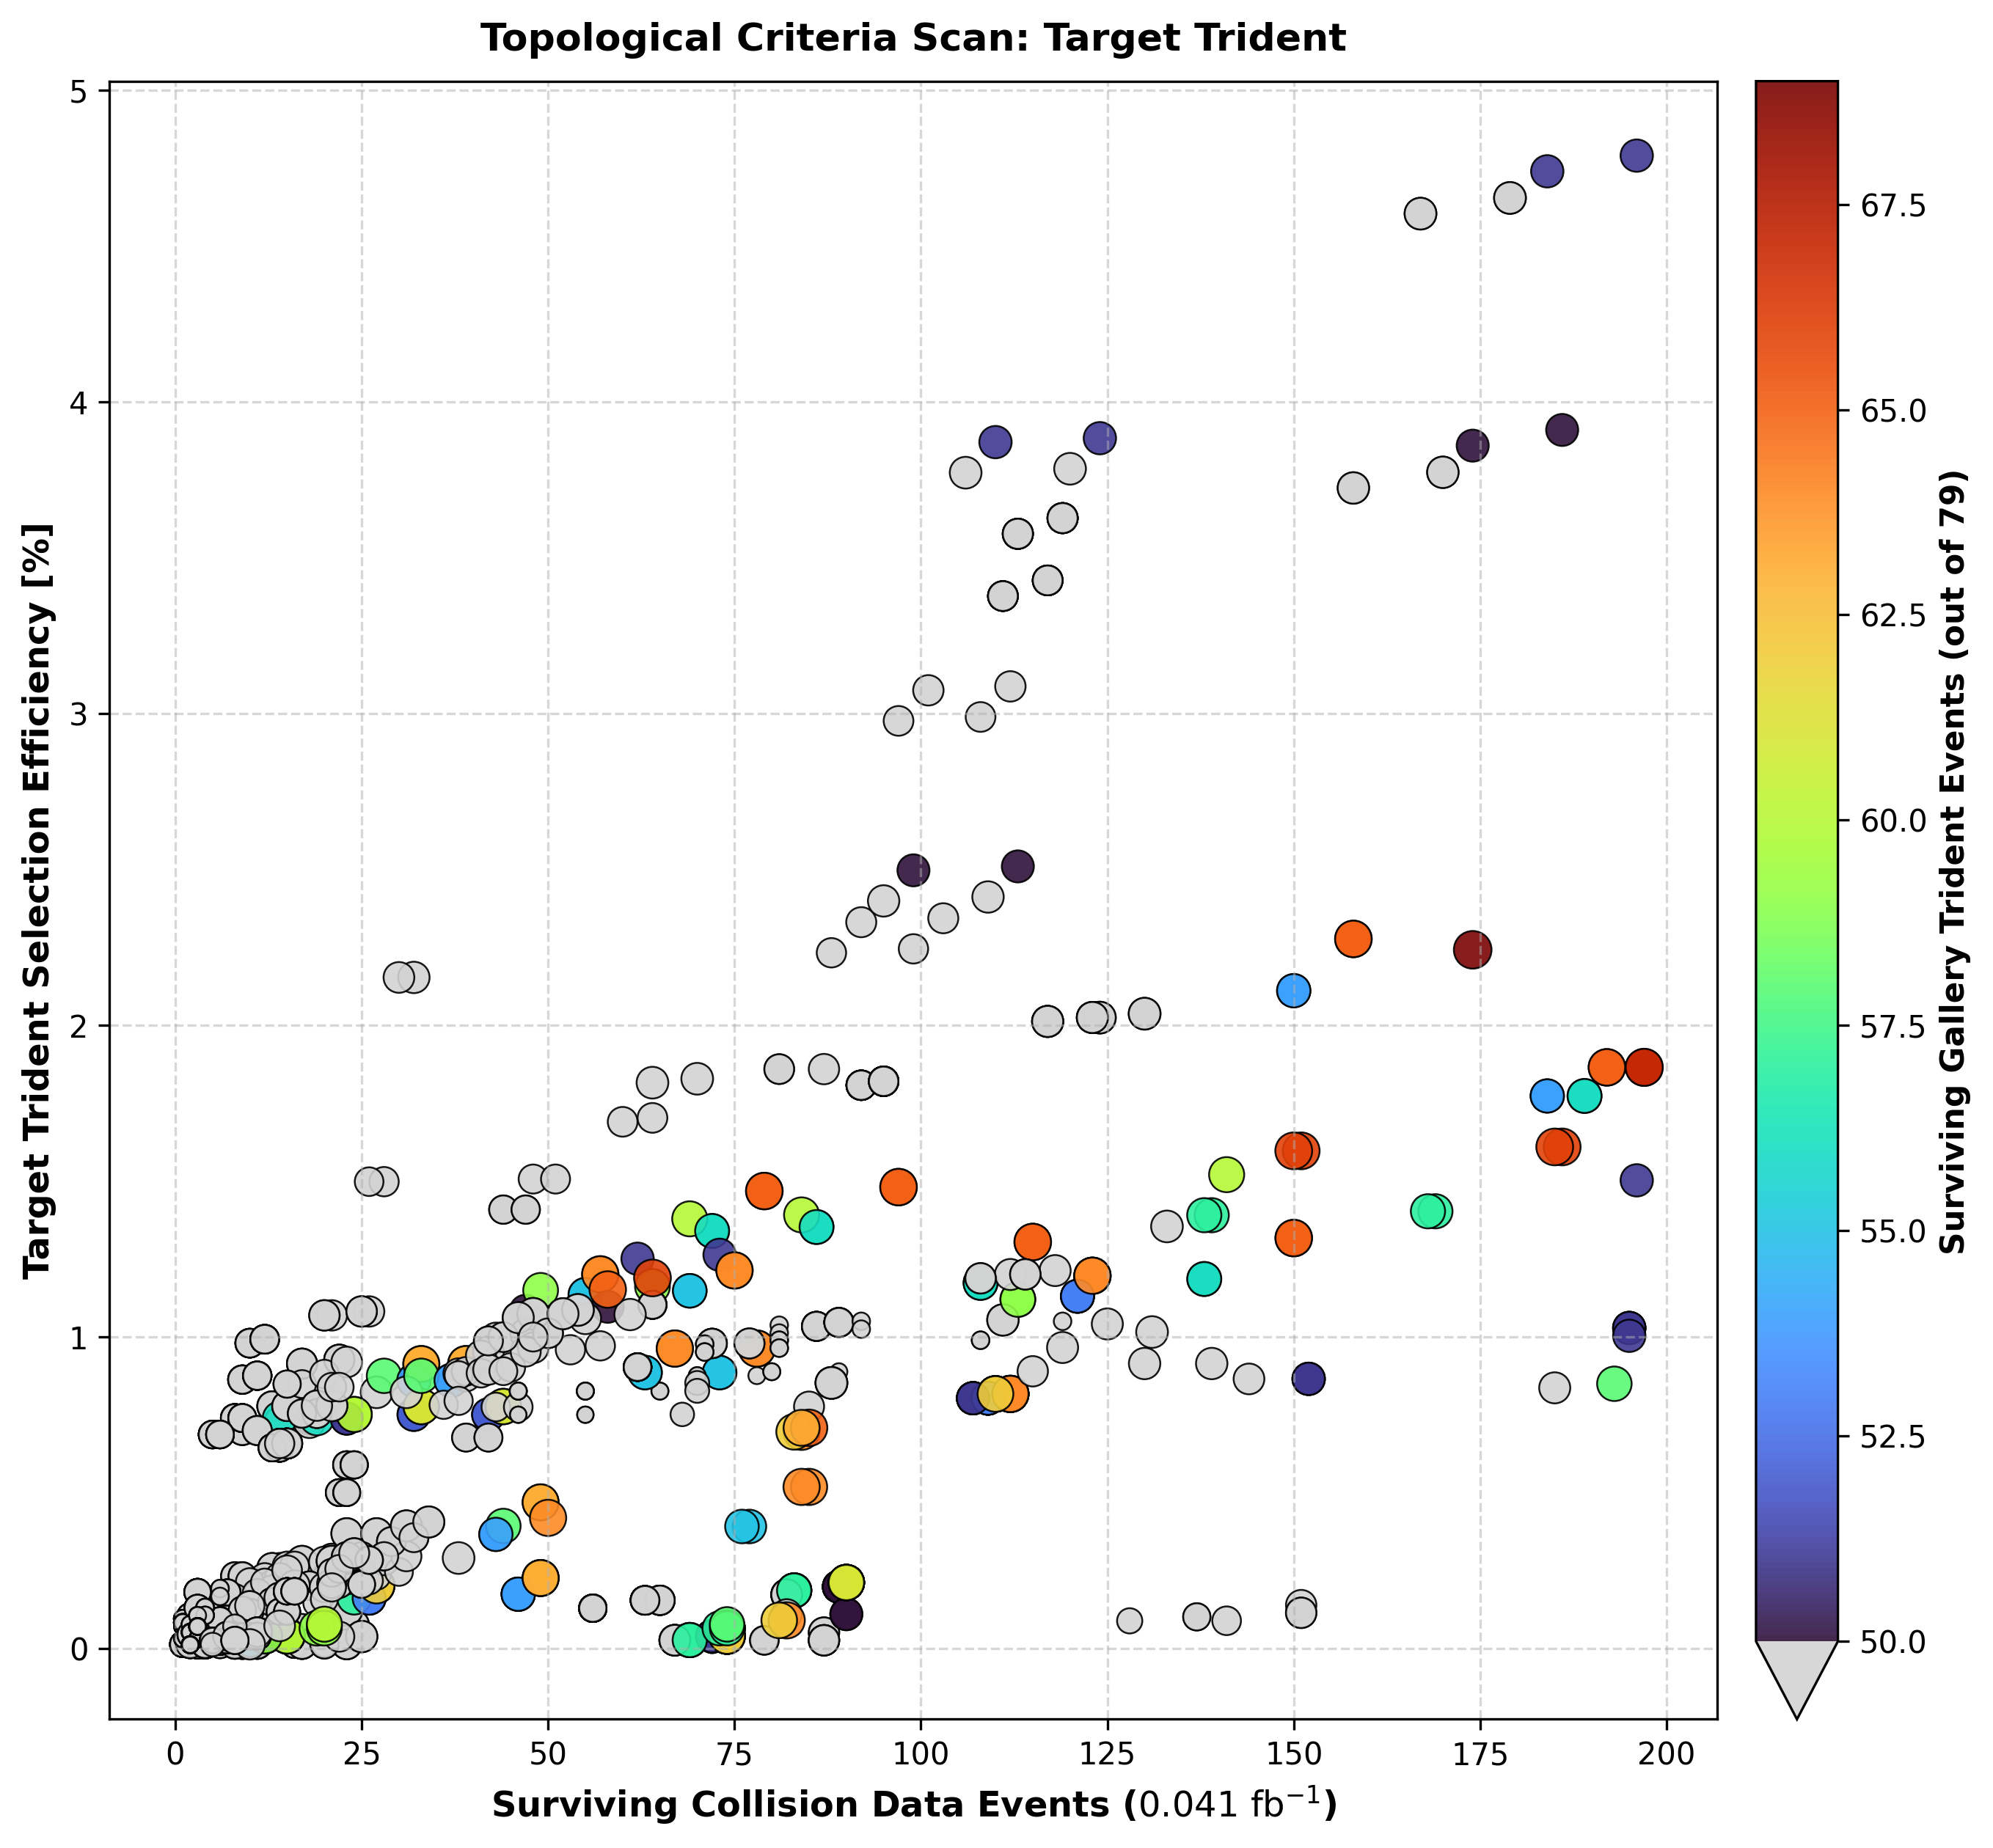

In [6]:
import ast
from pathlib import Path
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. LOAD PRECOMPUTED SCAN DATASET
# ==============================================================================
DATA_PATH = Path("data/topological_criteria_scan_all_regions.parquet")
OUT_PLOT_DIR = Path("plots")
OUT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

df_all = pd.read_parquet(DATA_PATH)


def format_intuitive_label(lbl: str) -> str:
    """Converts technical tuple strings into clean, readable physics expressions."""
    try:
        parts = ast.literal_eval(lbl)
    except (ValueError, SyntaxError, TypeError):
        return lbl

    mode = parts[0]
    if mode == "FACTORIZED_OR_AND":
        n1, n2 = parts[1]
        csf, cds = parts[2]
        m_str = (
            f"[SF({n1},{n2}) | DS({n1},{n2})]"
            if (n1, n2) != (3, 0)
            else "(SF_3 | DS_3)"
        )
        if csf == "OR" and cds == "OR":
            c_str = "(SF_nc & DS_nc)"
        elif csf == "AND" and cds == "OFF":
            c_str = "(SF_nc_both)"
        elif csf == "AND" and cds == "OR_phys":
            c_str = "(SF_nc_both & DS_nc_phys)"
        elif csf == "OR" and cds == "OFF":
            c_str = "(SF_nc)"
        else:
            c_str = f"(SF:{csf} & DS:{cds})"
        return f"{m_str} & {c_str}"

    if mode == "SF_ONLY":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        return f"SF({sf_m[0]},{sf_m[1]})_{sf_c} ONLY"

    if mode == "DS_ONLY":
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return f"DS({ds_m[0]},{ds_m[1]})_{ds_c} ONLY"

    if mode == "AND":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return (
            f"SF({sf_m[0]},{sf_m[1]})_{sf_c} & DS({ds_m[0]},{ds_m[1]})_{ds_c}"
        )

    if mode == "OR":
        sf_m, sf_c = parts[1][:2], parts[1][2]
        ds_m, ds_c = parts[2][:2], parts[2][2]
        return (
            f"SF({sf_m[0]},{sf_m[1]})_{sf_c} OR DS({ds_m[0]},{ds_m[1]})_{ds_c}"
        )

    return lbl


df_all["clean_label"] = df_all["label"].apply(format_intuitive_label)


# ==============================================================================
# 2. TOPOLOGICAL CRITERIA SCAN (MANUAL BOUNDS & AUTO AXIS SCALING)
# ==============================================================================
def plot_criteria_scan(
    region="rock",
    cmin=60,
    cmax=None,
    sweet_spot_bounds=None,
    save_fig=True,
):
    """Plots topological criteria scan with flexible color thresholds and optional sweet spot.

    Parameters
    ----------
    region : str
        'rock', 'target', 'mufilter', or 'total'.
    cmin : float
        Lower threshold for the colorbar (values below render gray).
    cmax : float or None
        Upper threshold for the colorbar (defaults to max surviving gallery events).
    sweet_spot_bounds : tuple (x_min, x_max, y_min, y_max) or None
        Explicit coordinates to draw the sweet spot box, e.g. (0, 100, 45.0, 100.0).
        If None, no sweet spot box or guideline is drawn.
    save_fig : bool
        Whether to save the figure to OUT_PLOT_DIR.
    """
    eff_col = (
        f"{region}_eff_pct" if region != "total" else "total_signal_eff_pct"
    )
    sig_name = {
        "rock": "Rock Trident",
        "target": "Target Trident",
        "mufilter": "Muon Filter Trident",
        "total": "Total Trident (All Regions)",
    }.get(region, region.title())

    df_zoom = df_all[
        (df_all["data_events"] > 0) & (df_all["data_events"] <= 200)
    ].copy()

    custom_cmap = mpl.colormaps["turbo"].copy()
    custom_cmap.set_under("lightgray")

    fig, ax = plt.subplots(figsize=(9.5, 8.5), dpi=300)

    if cmax is None:
        cmax = df_zoom["gallery_events"].max()

    sc = ax.scatter(
        df_zoom["data_events"],
        df_zoom[eff_col],
        c=df_zoom["gallery_events"],
        s=df_zoom["gallery_events"] * 2.2,
        cmap=custom_cmap,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.6,
        vmin=cmin,
        vmax=cmax,
    )

    cbar = fig.colorbar(sc, ax=ax, pad=0.02, extend="min")
    cbar.set_label(
        "Surviving Gallery Trident Events (out of 79)",
        fontweight="bold",
        fontsize=10.5,
    )

    # --------------------------------------------------------------------------
    # Optional Manual Sweet Spot Box
    # --------------------------------------------------------------------------
    if sweet_spot_bounds is not None:
        x_min, x_max, y_min, y_max = sweet_spot_bounds
        box_width = x_max - x_min
        box_height = y_max - y_min

        ul_box = patches.Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            linewidth=2,
            edgecolor="red",
            facecolor="pink",
            alpha=0.22,
            linestyle="--",
            label=(
                rf"Sweet Spot: Data $\in [{x_min}, {x_max}]$ & Eff $\in"
                rf" [{y_min}, {y_max}]\%$"
            ),
        )
        ax.add_patch(ul_box)
        ax.axvline(x_max, color="red", linestyle="--", linewidth=1.3)
        ax.axhline(y_min, color="blue", linestyle="--", linewidth=1.3)
        ax.legend(loc="lower right", fontsize=10.5)

    ax.set_xlabel(
        r"Surviving Collision Data Events ($0.041\ \mathrm{fb}^{-1}$)",
        fontweight="bold",
        fontsize=11.5,
    )
    ax.set_ylabel(
        f"{sig_name} Selection Efficiency [%]",
        fontweight="bold",
        fontsize=11.5,
    )
    ax.set_title(
        f"Topological Criteria Scan: {sig_name}",
        fontweight="bold",
        fontsize=12.5,
        pad=10,
    )
    ax.grid(True, linestyle="--", alpha=0.5)

    # Automatic margin padding instead of hardcoded xlim / ylim
    ax.autoscale(enable=True, axis="both", tight=False)

    plt.tight_layout()
    if save_fig:
        out_file = OUT_PLOT_DIR / f"scan_{region}_plot.png"
        plt.savefig(out_file)
        print(f"Saved figure to: {out_file}")
    plt.show()


# Example 1: Target scan without sweet spot, custom color floor at 50 events
plot_criteria_scan(region="target", cmin=50, sweet_spot_bounds=None)

# Example 2: Rock scan with manual (x_min, x_max, y_min, y_max) sweet spot bounds
# plot_criteria_scan(
#     region="rock",
#     cmin=60,
#     cmax=79,
#     sweet_spot_bounds=(0, 100, 47.5, 100.0),
# )

Saved figure to: plots/sweet_spot_target_plot.png


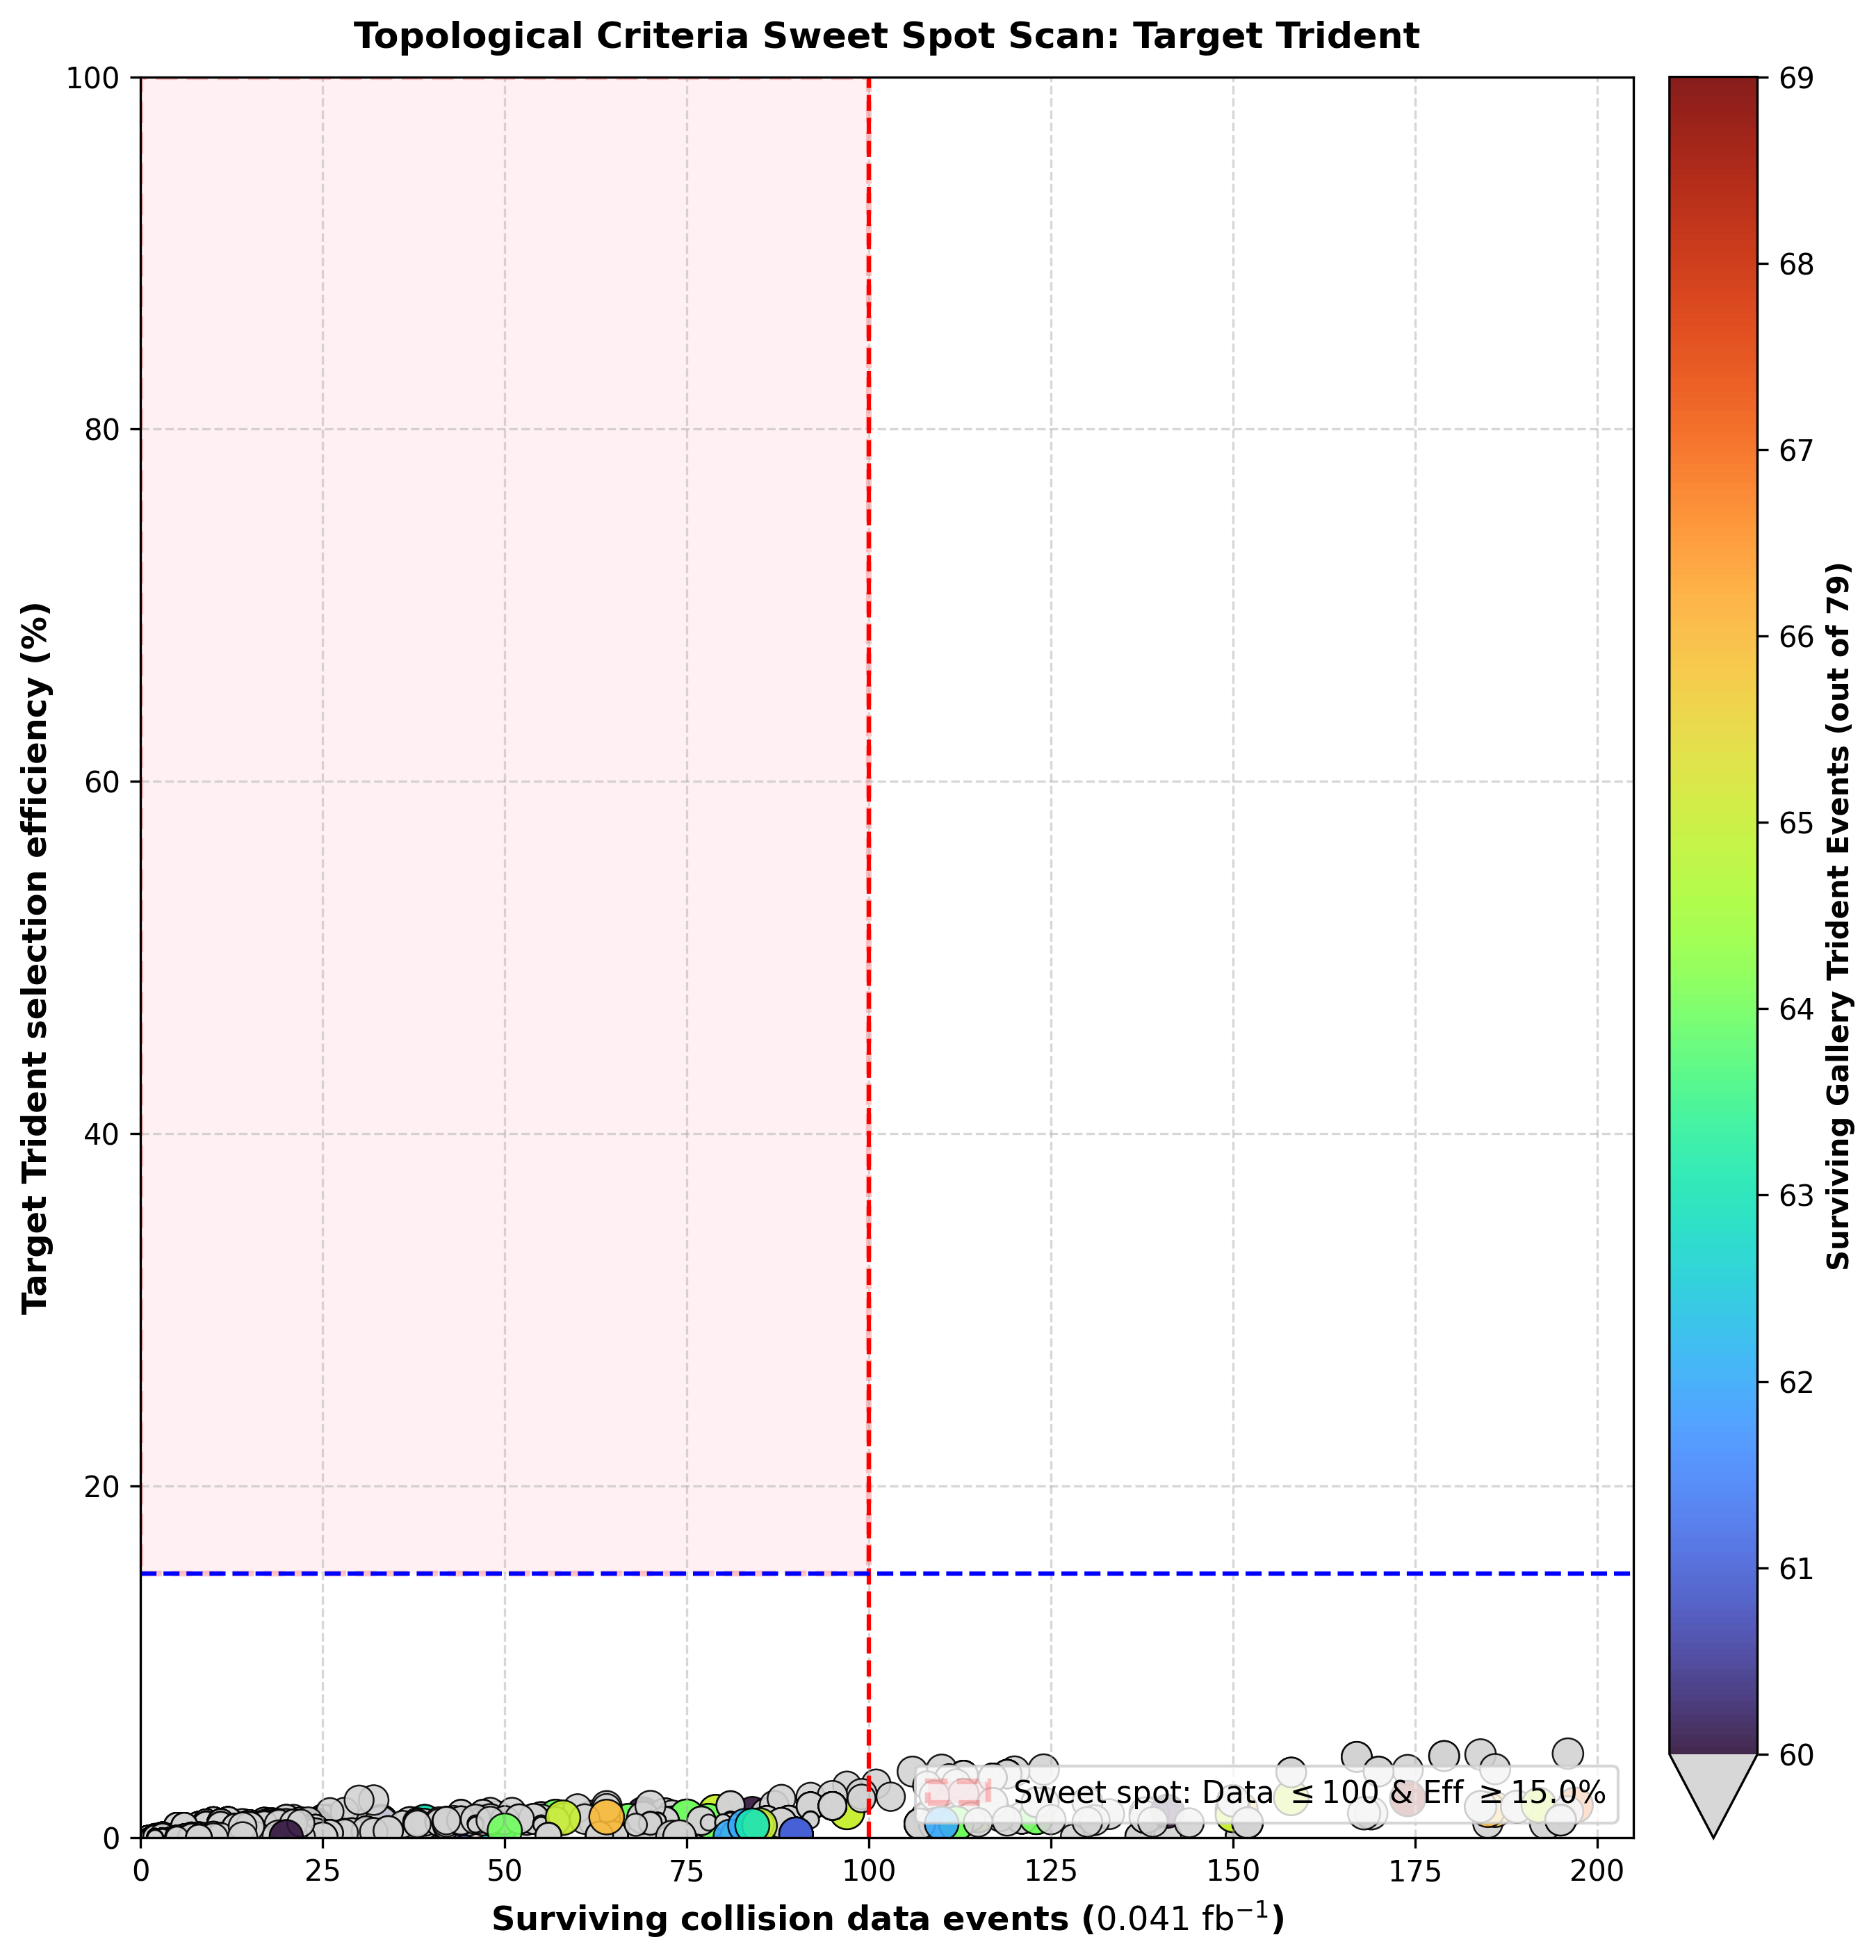

In [2]:
plot_sweet_spot(region='target', eff_threshold=15.0)